<a href="https://colab.research.google.com/github/fernandodeeke/can2025/blob/main/regressao_linear_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h3></h3></center>
<center><h1>Análise Numérica</h1></center>
<center><h2>2026/1</h2></center>
<center><h3>Técnicas de Regressão Linear Univariada</h3></center>
<center><h4>Prof. Fernando Deeke Sasse - CCT, UDESC</h4></center>

###  Ajuste de retas pelo método de mínimos quadrados

Usaremos a biblioteca opimize do scypy:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

#### Exemplo 1

Suponhamos que um experimento que descreve uma relação $x=x(t)$ produz os resultados mostrados na tabela abaixo:

In [ ]:
T = np.array([1.3,3.3,4.1,6.4,7.3,9.2])
X = np.array([2.5,3.8,4.2,5.2,6.5,7.3])

Façamos um gráfico destes pontos:

Text(0, 0.5, 'X')

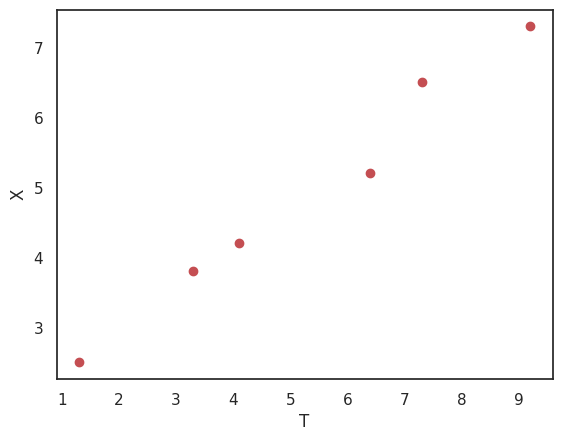

In [ ]:
plt.plot(T,X,'ro')
plt.xlabel('T')
plt.ylabel('X')

Uma conclusão razoável é que a função $x(t)$ é linear e que o fato dos pontos não estarem exatamente sobre uma linha reta é devido a erros experimentais. Um vez feita tal suposição podemos nos perguntar como podemos determinar os coeficientes $a$ e $b$ reta
$$
                           x = at + b
$$  
que melhor se ajusta a esses dados.


Suponhamos que uma suposição é feita sobre os valores de $a$ e $b$. Em geral,um ponto $(T_k,X_k)$ não estará exatamente sobre a reta, ou seja,

$$
aT_k+b-X_k \neq 0
$$

Podemos definir um erro absoluto associado a este ponto, que depende de $a$ e $b$, dado por

$$
                 E_k(a,b)=|aT_k+b-X_k|
$$

Supondo que, em geral, temos $n$ pontos, o erro total $E(a,b)$ é a soma dos erros associados a todos os $n$ pontos:

$$
               E(a,b)=\sum_{i=1}^{n} |aT_k+b-X_k|
$$

A próxima tarefa consiste em encontrar o ponto $(a,b)$ que minimiza esta função.

Este problema éum exemplo de uma  aproximação $L_1$ e que pode ser resolvido por meio de técnicas de programação linear. Dependendo do número de pontos a complexidade deste problema em termos de número de operações pode ser muito custosa. O métodos do cálculo diferencial não podem ser aplicados, pois esta função não é diferenciável.


Na prática, é mais conveniente minimizar a seguinte função de erro de $a$ e $b$:

$$
\phi(a,b)=\sum_{i=1}^{n} (aT_k+b-X_k)^2,
$$

que pode ser minimizada por meio de técnicas de cálculo. ALém disso, é possível mostrar que se os erros têm uma distribuição normal, então a minimização de $\phi(a,b)$ produz o melhor estimador de $a$ e $b$. Esta é a chamada aproximação $L_2$.

As condições necessárias para que um ponto $(a,b)$ seja um mínimo de $\phi$ são

$$
\frac{\partial \phi}{\partial a}=0\,,\qquad \frac{\partial \phi}{\partial b}=0\,.
$$

Em particular,

$$
\frac{\partial \phi}{\partial a}=\sum_{i=1}^{n} 2T_k(aT_k+b-X_k)=0
$$

e

$$
\frac{\partial \phi}{\partial b}=\sum_{i=1}^{n} 2(aT_k+b-X_k)=0\,.
$$

Estas equações, chamadas *normais* podem ser também escritas como



$$
\left(\sum_{k=1}^n T_k^2\right)a+\left(\sum_{k=1}^n T_k\right)b= \sum_{k=1}^n T_k X_k,
$$

$$
\left(\sum_{k=1}^n T_k\right)a+nb=\sum_{k=1}^n X_k.
$$

Definindo

$$
p = \sum_{k=1}^n T_k\,,\quad q=\sum_{k=1}^n X_k\,,\quad
r=\sum_{k=1}^n T_k X_k\,,\quad s=\sum_{k=1}^n T_k^2\,,
$$

temos, de forma matricial,

$$
\begin{bmatrix}
s&p\\p&n
\end{bmatrix}=
\begin{bmatrix}
a\\b
\end{bmatrix}=\begin{bmatrix}
r\\q
\end{bmatrix}\,.
$$

Definindo

$$
\Delta = det \begin{bmatrix}
s&p\\p&n
\end{bmatrix} = ns-p^2\,,
$$

temos, usando a regra de Cramer,

$$
a = \frac{1}{\Delta}det\begin{bmatrix}
r&p\\q&n
\end{bmatrix}=\frac{1}{d}(rn-pq)\,,
$$

$$
b = \frac{1}{\Delta}det\begin{bmatrix}
s&r\\p&q
\end{bmatrix}=\frac{1}{d}(sq-pr)\,.
$$

Voltemos ao nosso problema. Temos aqui

In [ ]:
p = np.sum(T)
q = np.sum(X)
r = np.sum(T*X)
s = np.sum(T**2)
n = np.size(T)

In [ ]:
d = n*s-p**2

O coeficiente angular da reta é dado por

In [ ]:
a = 1/d*(r*n-p*q)
a

np.float64(0.6100669002867147)

O coeficiente linear é:

In [ ]:
b = 1/d*(s*q-p*r)
b

np.float64(1.7036476584899696)

Façamos o gráfico da reta:

In [ ]:
t = np.linspace(0, 10,100)

Text(0, 0.5, 'x')

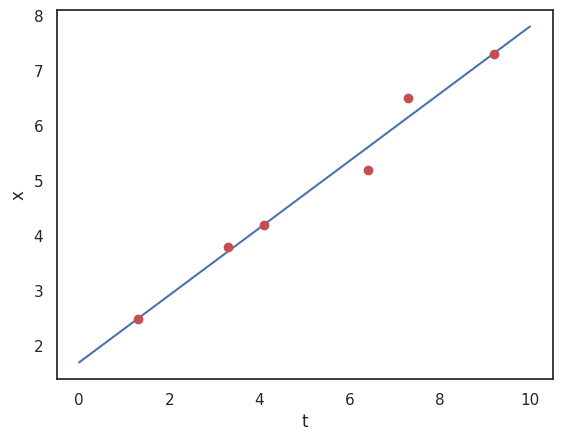

In [ ]:
plt.plot(t,a*t+b)
plt.plot(T,X,'ro')
plt.xlabel('t')
plt.ylabel('x')

Visualmente o ajuste parece bem feito. Podemos agora determinar $x(t)$ para valores não tabelados. Por exemplo determinemos $x(4.5)$. A função que define a reta é dada por

In [ ]:
def f(t, a, b):
    return a*t + b

Portanto,

In [ ]:
round(f(4.5,a,b),2)

np.float64(4.45)

Podemos resolver este problema diretamente, usando o comando curve_fit do scipy:

In [ ]:
from scipy.optimize import curve_fit

In [ ]:
def g(t, a, b):
    return a*t+b

O comando que realiza o ajuste pelo método de mínimos quadrados é o seguinte:

In [ ]:
param, pcov = curve_fit(g, T, X)

O primeiro argumento é o array com os valores dos parâmetros (o segundo é a matriz de covariância, que não nos interessa neste momento):

In [ ]:
param

array([0.6100669 , 1.70364766])

que são os mesmos valores encontrados anteriormente. Façamos o gráfico correspondente:

Text(0, 0.5, 'x')

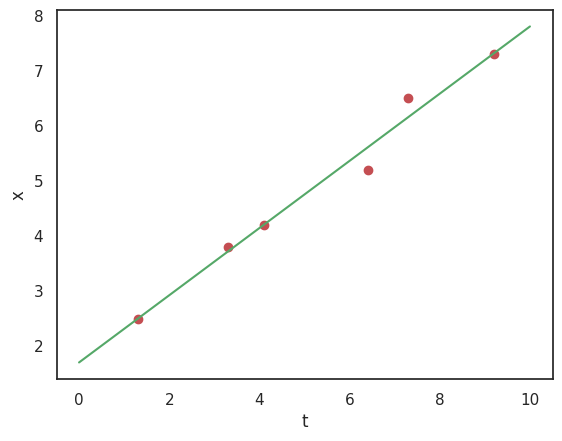

In [ ]:
plt.plot(T,X,'ro', t, g(t, *param), 'g-')
plt.xlabel('t')
plt.ylabel('x')

Podemos quantificar o erro no ajuste calculando o erro quadrático médio. Definimos o array que calcula o valor da função $g(t)$, agora com os parâmetros determinados, em cada componente do array $T$:

In [ ]:
F = g(T,*param)
F

array([2.49673463, 3.71686843, 4.20492195, 5.60807582, 6.15713603,
       7.31626314])

Podemos agora calcular o erro quadrático médio:

In [ ]:
n=len(F)
np.sum(F-X)**2/n

np.float64(5.437925012953547e-22)

### Ajuste de funções quaisquer pelo método de mínimos quadrados

#### Exemplo 2.
A técnica acima pode ser generalizada para ajustar qualquer função a um conjunto de dados. Por exemplo, suponhamos que temos os dados:

In [ ]:
x = np.array([1., 1.5,2.,3.,4.,5.])
y = np.array([5.3,6.4,8.2,7.2,6.6,4.3])

Façamos um gráfico destes pontos:

Text(0, 0.5, 'y')

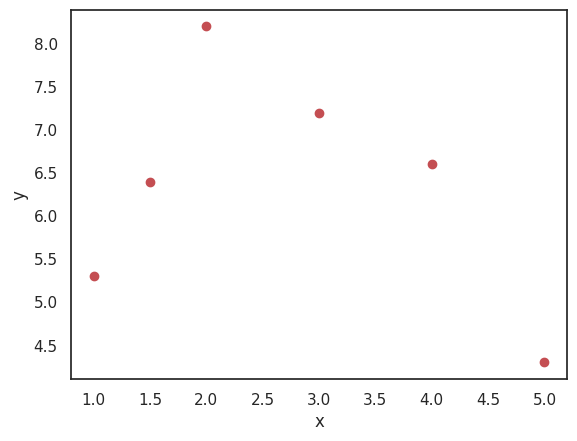

In [ ]:
plt.plot(x,y,'ro')
plt.xlabel('x')
plt.ylabel('y')

Se quisermos, por exemplo ajustar a função $f(x) = a+bx+cx^2+d\mbox{e}^{-x}$ a estes dados, devemos minimizar o erro:

$$
\phi(a,b,c,d)=\sum_{k=1..n}(a+bx_k+cx_k^2+d\mbox{e}^{-x_k}-y_k)^2
$$

O ponto de mínimo deve satisfazer:

$$
\frac{\partial \phi}{\partial a}=0\,,\quad \frac{\partial \phi}{\partial b}=0\,,\quad
\frac{\partial \phi}{\partial c}=0\,,\quad
\frac{\partial \phi}{\partial d}=0\,.
$$

Como os parâmetros a serem determinados aparecem linearmente, estas 4 condições geram 4 equações lineares que determinam os valores dos parâmetros que minimizam o erro. Note que se os parâmetros aparecerem de forma não linear na função de ajuste, a correspondente equação para os parâmetros será não-linear e sua solução pode ser difícil de ser encontrada.

Façamos o ajuste diretamente, usando comandos do Python:

In [ ]:
def h(t, a, b,c,d):
    return a + b*t+c*t**2 +d*np.exp(-t)

In [ ]:
param, pcov = curve_fit(h, x, y)

In [ ]:
param

array([  9.94130347,   0.24101929,  -0.26833019, -12.80943743])

Façamos o gráfico correspondente:

In [ ]:
t = np.linspace(0.9, 5.1,30)

Text(0, 0.5, 'y')

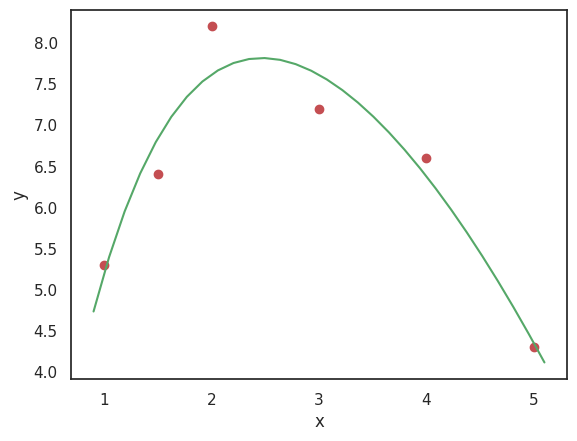

In [ ]:
plt.plot(x,y,'ro', t, h(t, *param), 'g-')
plt.xlabel('x')
plt.ylabel('y')

Podemos quantificar o erro no ajuste calculando o erro quadrático médio. Definimos o array que calcula o valor da função $f$, agora com os parâmetros determinados, em cada componente do array $x$:

In [ ]:
H = h(x,*param)
H

array([5.2016639 , 6.84091767, 7.61645247, 7.61164534, 6.37748464,
       4.35183597])

Lembremos que os valores das ordenadas (valores observados de $y$) são dados por:

In [ ]:
y

array([5.3, 6.4, 8.2, 7.2, 6.6, 4.3])

Podemos agora calcular o erro quadrático médio:

In [ ]:
n=len(y)
np.sum(H-y)**2/n

np.float64(2.612037485647759e-17)

Suponhamos que queremos inferir o valor de $y(4.5)$ e $y(5.7)$:

In [ ]:
np.round(h(np.array([4.5,5.7]),*param),2)

array([5.45, 2.55])

### Coeficiente de determinação e coeficiente de correlação

Na regressão linear, o objetivo é encontrar um modelo que explique a relação entre uma variável dependente $y$ e uma ou mais variáveis ​​independentes $x$. O **método dos mínimos quadrados** é uma abordagem padrão que minimiza a soma dos quadrados dos resíduos:

$$
\text{SSE} = \sum_{i=1}^n(\hat{y}_i-y_i)^2
$$

sendo $\hat{y}_i$ são os valores previstos pelo modelo e $y_i$ são os valores observados nos dados.

O **coeficiente de determinação**, denotado por $r^2$, é uma medida de quão bem o modelo de regressão explica a variabilidade dos dados de resposta em torno de sua média. É definido como:

$$
r^2 = 1 - \frac{\text{SSE}}{\text{SST}}\,,
$$

sendo que $\text{SSE}$ (*sum of squared estimate of errors*)   é a  **soma dos erros quadrados**:
$$
\text{SSE} := \sum (y_i - \hat{y}_i)^2
$$
e  $\text{SST}$ (*sum of squares total*)  é a **soma total dos quadrados**:
$$
\text{SST}:=\sum (y_i - \bar{y})^2\,.
$$

Alternativamente, somente no caso de regressão linear simples, com mínimos quadrados,  $r^2$ pode ser expresso como:

$$
r^2 = \frac{\text{SSR}}{\text{SST}}
$$

sendo que $\text{SSR}$ é a **soma dos quadrados da regressão**, medindo a variância explicada pelo modelo:

$$
\text{SSR} = \sum (\hat{y}_i - \bar{y})^2\,.
$$

Para mais detalhes veja:

- [Penn State STAT 462 — 2.5: The Coefficient of Determination, r-squared](https://online.stat.psu.edu/stat462/node/95/)
- [University of Colorado — Chapter 12: Simple Linear Regression](https://www.colorado.edu/amath/sites/default/files/attached-files/ch12_0.pdf)

Notemos que:

- $r^2 = 1$: o modelo explica toda a variabilidade nos dados de resposta.
- $r^2 = 0$: o modelo não explica nenhuma variabilidade; não é melhor do que prever a média.
- $0 < r^2 < 1$: a proporção da variabilidade explicada pelo modelo.


Na regressão linear simples (presente caso), $r^2$ também é o quadrado do **coeficiente de correlação de Pearson** entre $x$ e $y$. A quantidade $r$ é denominada **coefficiente de correlação**.

#### Exemplo 3.
Façamos ajuste e determinemos o coeficiente de determinação para os seguintes dados.

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Dados
x = np.array([1., 2., 3., 4., 5. ,6. , 7., 8.])
y = np.array([2.3, 6.4, 8.2, 7.2, 6.6, 4.3, 2.3, 1.4])

# Modelo
def h(t, a, b, c,d):
    return a + b*t + c*t**2 + d*np.exp(-t)
    #return a + b*t + c*t**2

# Ajuste da curva
param, pcov = curve_fit(h, x, y)

Façamos o gráfico:

Text(0, 0.5, 'y')

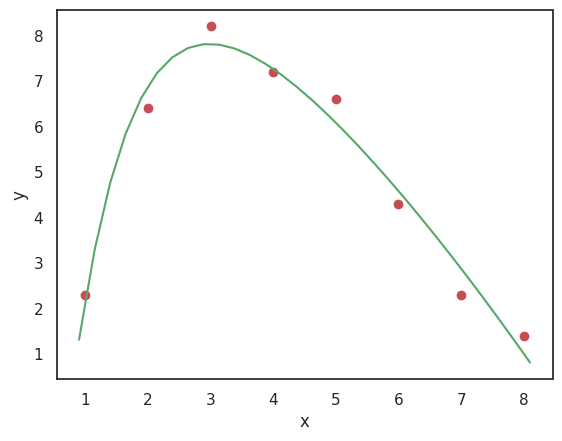

In [ ]:
t = np.linspace(0.9, 8.1,30)
plt.plot(x,y,'ro', t, h(t, *param), 'g-')
plt.xlabel('x')
plt.ylabel('y')

Calculemos o coeficiente de determinação:

In [ ]:
y_pred = h(x, *param)
y_mean = np.mean(y)
ss_total = np.sum((y - y_mean)**2)
ss_res = np.sum((y - y_pred)**2)

r2 = 1 - ss_res / ss_total

print(f"r²= {r2:.4f}")

r²= 0.9739


Os resultados indicam que 97,39% da incerteza original foi explicada por esse modelo. Esse resultado confirma a conclusão de que a equação quadrática representa um bom ajuste, como também é evidente a partir do gráfico.


Façamos a predição em $x=4.5$:

In [ ]:
round(h(4.5,*param),2)

np.float64(6.73)

## Exercícios

Em cada um dos problemas abaixo:

1. Ajuste a reta de regressão linear
   $$
   \hat y = a + bx
   $$
   pelo método dos mínimos quadrados.

2. Calcule os valores previstos $\hat y_i$ para cada observação.

3. Calcule:
   $$
   \mathrm{SSE}=\sum_{i=1}^n (y_i-\hat y_i)^2
   $$
   $$
   \mathrm{SST}=\sum_{i=1}^n (y_i-\bar y)^2
   $$
   $$
   \mathrm{SSR}=\sum_{i=1}^n (\hat y_i-\bar y)^2
   $$

4. Verifique que
   $$
   \mathrm{SST}=\mathrm{SSR}+\mathrm{SSE}.
   $$

5. Calcule o coeficiente de determinação:
   $$
   r^2 = 1-\frac{\mathrm{SSE}}{\mathrm{SST}}
   $$
   e também
   $$
   r^2 = \frac{\mathrm{SSR}}{\mathrm{SST}}.
   $$

6. Interprete o valor obtido para $r^2$.

Resolva os problemas 1 a 6, passo e depois verifique seu resultado usando curve.fit.

**1.** Um estudante quer relacionar o número de horas de estudo $x$ com a nota obtida em um teste $y$.

| $x$ | 0.5| 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|---:|
| $y$ | 2| 4 | 4.5 | 7.5 | 9 |

Determine a reta de regressão linear e calcule o coeficiente de determinação.

**2.** Uma fábrica observa o número de operários em uma equipe $x$ e a quantidade de peças produzidas por hora $y$.

| $x$ | 1 | 2 | 3 | 4 | 5 |
|---|---:|---:|---:|---:|---:|
| $y$ | 3 | 4 | 4 | 6 | 8 |

Determine a reta de mínimos quadrados e calcule $r^2$.


**3.** Um pesquisador mede a temperatura $x$ e o consumo de energia $y$ de um equipamento.

| $x$ | 0 | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|---:|
| $y$ | 1 | 2 | 2 | 4 | 5 |

Encontre a reta de regressão linear e calcule $\mathrm{SSE}$, $\mathrm{SSR}$, $\mathrm{SST}$ e $r^2$.

**4.** Em um experimento, a variável $x$ representa o tempo de funcionamento de uma máquina e $y$ representa a quantidade de falhas observadas.

| $x$ | 1 | 2 | 3 | 4 | 5 |
|---|---:|---:|---:|---:|---:|
| $y$ | 7 | 6 | 5 | 4 | 3 |

Ajuste a reta de regressão e calcule $r^2$. Interprete o resultado.

**5.** Uma loja registra o número de anúncios feitos em uma semana $x$ e o número de vendas realizadas $y$.

| $x$ | 2 | 4 | 6 | 8 |
|---|---:|---:|---:|---:|
| $y$ | 1 | 3 | 4 | 5 |

Use o método dos mínimos quadrados para ajustar uma reta aos dados e calcule o coeficiente de determinação.

**6.**  Use mínimos quadrados para ajustar uma parábola aos seguintes dados:

$ X = [0.2, 0.5, 0.8, 1.2, 1.7, 2.0, 2.3]$

$ Y = [500, 700, 1000, 1200, 2200, 2650, 3750] $

**7.** Considere a funções $f(t) = a+bt+ct^2+dt^3+f\mbox{e}^{-t}$ e $f(t) = a+bt+ct^2+dt^3+f t^4$ e verifique, usando curve_fit, se cada ajuste é melhor ou pior do que o do exemplo para os dados

x = np.array([1., 1.5,2.,3.,4.,5.])
y = np.array([5.3,6.4,8.2,7.2,6.6,4.3])

**8.** Determine uma função (escolha a forma), linear em 4 parâmetros, que se ajuste a estes dados, usando o método dos mínimos quadrados. Use curve_fit.
x = np.array([1.1,1.5,2.6, 2.8,3.3,4.3,5.4,6.8,7.3])
y = np.array([4.3,5.3,6.4,7.2,7.1,6.3,5.4, 3.5,3.2])

#### Observação

Lembre-se de que:

- $r^2 = 1$ indica ajuste perfeito;
- $r^2 = 0$ indica que o modelo não explica a variabilidade dos dados;
- quanto mais próximo de 1 estiver $r^2$, maior é a proporção da variabilidade de $y$ explicada pelo modelo.

### Método dos gradientes descendentes

O método descrito anteriormente funciona bem para funções de uma variável e quando o número de pontos não é muito grande. Descreveremos agora um método mais apropriado para lidar com ajuste de funções de uma ou mais variável, que funciona bem com um número muito grande de pontos. Nosso objetivo é modelar a relação entre uma variável dependente escalar $y$ e uma variável independente $x$ como:

$$
y \approx \hat{y} = \theta_0 + \theta_1 x\,.
$$

Devemos encontrar os parâmetros $\theta_0$ e $\theta_1$ que minimizem a discrepância entre os valores previstos $\hat{y}$ e os valores observados $y$. Essa discrepância é quantificada pela função de custo (Erro Quadrático Médio):

$$
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2 = \frac{1}{2m} \sum_{i=1}^{m} \left( \theta_0 + \theta_1 x^{(i)} - y^{(i)} \right)^2
$$

O método dos gradientes descendentes é um algoritmo de otimização iterativa para minimizar a função de custo $J(\theta_0, \theta_1)$. Os parâmetros são atualizados da seguinte forma:

$$
\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}
$$

para $j = 0, 1$, onde $\alpha$ é a taxa de aprendizado (tomando como positivo, pois buscamos um mínimo).

As derivadas parciais são:

$$
\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)
$$

$$
\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)x^{(i)}
$$

De modo mais compacto, para fins computacionais,  podemos reescrever:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)} )^2$$

onde $y^{(i)}$ são os valores observados e $h_{\theta}(x)$ é a hipótese, dada pelo modelo linear.

$$h_{\theta}(x) = \theta^T\mathbf{x} = \theta_0 + \theta_1x_1$$

sendo

$$
\theta^T = [\theta_0 \,\,\theta_1]\,,\qquad \mathbf{x}^T = [ 1,x_1]\,.
$$

#### Exemplo 4
Antes de usar o método em um problema prático, validaremos o método em um exemplo artificial, usando dados sintéticos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Gera dados sintéticos
np.random.seed(0)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)

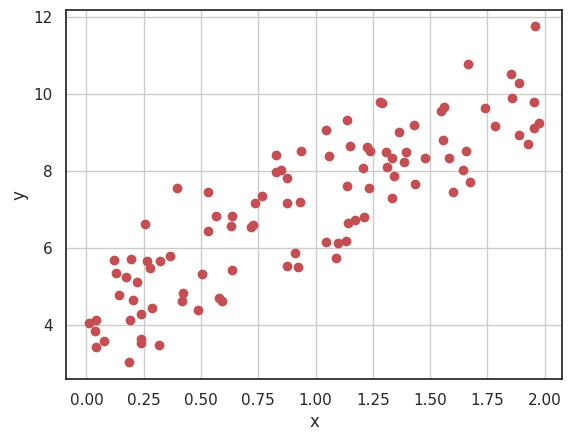

In [ ]:
plt.plot(x,y,'ro')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

Definimos o vetor de dados $\mathbf{x}^T = [ 1,x_1]$:

In [ ]:
X = np.c_[np.ones((100, 1)), x]
X[0:5]

array([[1.        , 1.09762701],
       [1.        , 1.43037873],
       [1.        , 1.20552675],
       [1.        , 1.08976637],
       [1.        , 0.8473096 ]])

Note que

In [ ]:
np.shape(X)

(100, 2)

Visualisemos alguns valores de X:

In [ ]:
X[0:5]

array([[1.        , 1.09762701],
       [1.        , 1.43037873],
       [1.        , 1.20552675],
       [1.        , 1.08976637],
       [1.        , 0.8473096 ]])

Definimos agora os parâmetros. O vetor de parâmetros $\theta=[\theta_0,\theta_1]^T$ terá valor inicial nulo:

In [ ]:
# Parâmetros
alpha = 0.1
n_it = 1000
m = len(x)
theta = np.zeros((2,1))

Façamos os cálculos:

In [ ]:
for _ in range(n_it):
    gradJ = 1/m * X.T @ (X @ theta - y)
    theta = theta - alpha * gradJ

print(f"Theta encontrado: {theta.ravel()}")

Theta encontrado: [4.222151   2.96846758]


In [ ]:
J = (1/(2*m)) * np.sum((X @ theta - y)**2)
J

np.float64(0.496219324362325)

Podemos agora mostrar os gráficos:

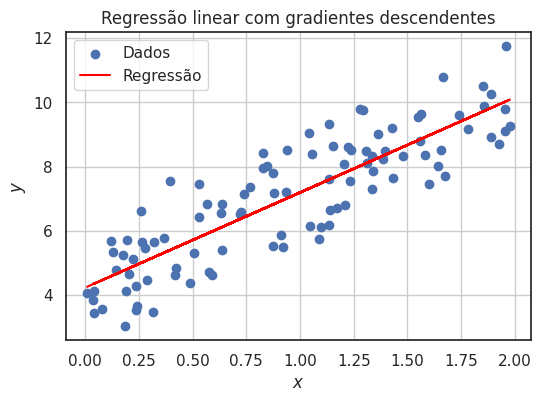

In [ ]:
plt.figure(figsize=(6, 4),dpi=100)
plt.scatter(x, y, label="Dados")
plt.plot(x, X @ theta, color='red', label="Regressão")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.title("Regressão linear com gradientes descendentes")
plt.grid(True)
plt.show()

Para encontrar um determinado valor sobre a reta, por exemplo, $y(1.5)$, podemos calcular:

In [ ]:
x = np.array([1,1.5])

de modo que

In [ ]:
x@theta

array([8.67485237])

ou

In [ ]:
def predict(x,theta):
    xx = np.array([1,x])
    y_pred = xx @ theta
    return round(y_pred.item(),4)

In [ ]:
predict(1.5,theta)

8.6749

#### Exemplo 5.
Utilizemos agora uma função que determina a reta de regressão:

In [ ]:
def grad(x,y):
    alpha = 0.01
    n_it = 1000
    m = len(x)
    theta = np.zeros((2,1))
    X = np.c_[np.ones((m, 1)), x]
    for _ in range(n_it):
        gradJ = 1/m * X.T @ (X @ theta - y)
        theta = theta - alpha * gradJ
    return theta

In [ ]:
# Gera dados sintéticos
np.random.seed(0)
x = 3 * np.random.rand(10, 1)
y = 2 + 3.5 * x + np.random.randn(10, 1)

In [ ]:
np.shape(x)

(10, 1)

In [ ]:
np.shape(y)

(10, 1)

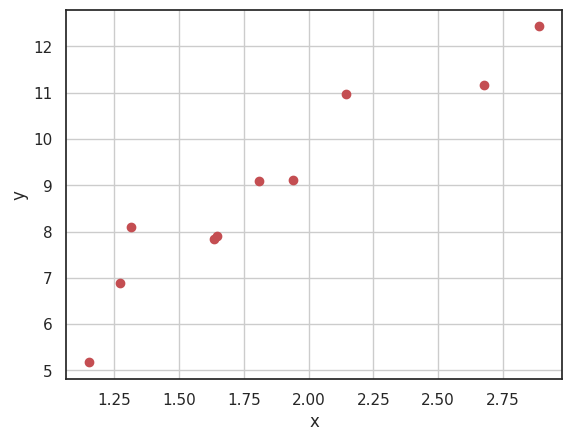

In [ ]:
plt.plot(x,y,'ro')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

Os coeficientes da reta de regressão são:

In [ ]:
theta = grad(x,y)
theta

array([[2.11855942],
       [3.64430829]])

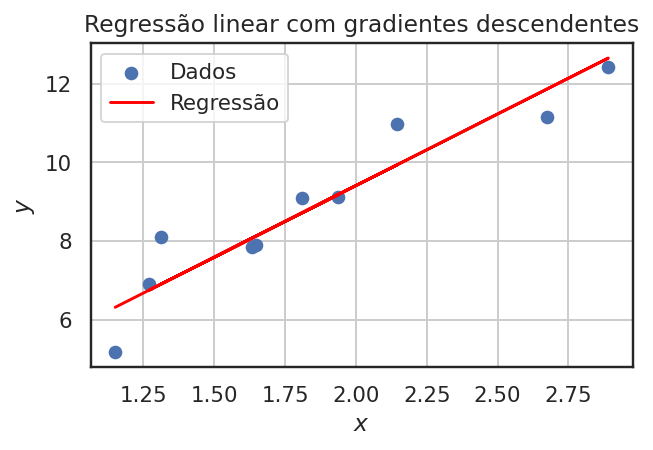

In [ ]:
m = len(x)
X = np.c_[np.ones((m, 1)), x]
plt.figure(figsize=(5, 3),dpi=140)
plt.scatter(x, y, label="Dados")
plt.plot(x, X @ theta, color='red', label="Regressão")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.title("Regressão linear com gradientes descendentes")
plt.grid(True)
plt.show()

#### Exemplo 6.
Vejamos um exemplo [1] que envolve a relação dos lucros de uma companhia que faz compartilhamento de bicicletas e a população da cidade na qual esta companhia oferece o serviço. Importaremos os dados do arquivo bike_sharing_data.txt. Usaremos a biblioteca pandas para melhor visualização dos dados:

In [ ]:
import pandas as pd

In [ ]:
url = "https://raw.githubusercontent.com/ShwetaBarge/LinearRegressionwithNumPyandPython/branch_0/bike_sharing_data.txt"
data = pd.read_csv(url)

Podemos visulizar as primeiras linhas do arquivo:

In [ ]:
data.head()

,Population,Profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


Os dados das duas colunas estão em unidades de 10000. Outras informações podem ser obtidas por meio do atributo:

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Population  97 non-null     float64
 1   Profit      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


Ou seja, temos dados de 97 cidades. Façamos um gráfico:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

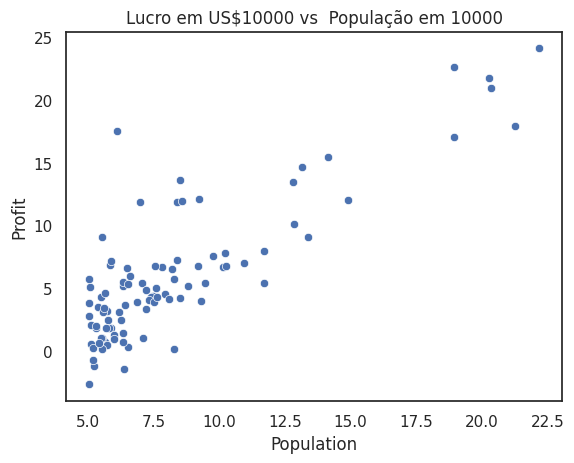

In [ ]:
ax = sns.scatterplot(x= "Population", y="Profit", data=data)
ax.set_title("Lucro em US$10000 vs  População em 10000");

Usando ggplot, temos um estilo mais elegante de gráfico:

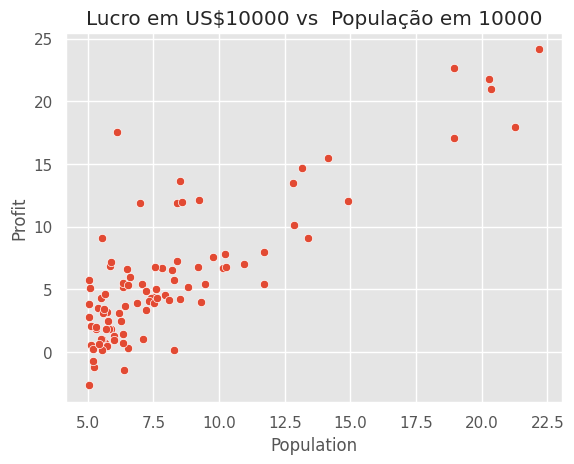

In [ ]:
plt.style.use('ggplot')
ax = sns.scatterplot(x= "Population", y="Profit", data=data)
ax.set_title("Lucro em US$10000 vs  População em 10000");

Este gráfico indica que um ajuste linear é, aparentemente,  apropriado.

In [ ]:
m = data.Population.values.size
m

97

In [ ]:
x = data.Population.values
x

array([ 6.1101,  5.5277,  8.5186,  7.0032,  5.8598,  8.3829,  7.4764,
        8.5781,  6.4862,  5.0546,  5.7107, 14.164 ,  5.734 ,  8.4084,
        5.6407,  5.3794,  6.3654,  5.1301,  6.4296,  7.0708,  6.1891,
       20.27  ,  5.4901,  6.3261,  5.5649, 18.945 , 12.828 , 10.957 ,
       13.176 , 22.203 ,  5.2524,  6.5894,  9.2482,  5.8918,  8.2111,
        7.9334,  8.0959,  5.6063, 12.836 ,  6.3534,  5.4069,  6.8825,
       11.708 ,  5.7737,  7.8247,  7.0931,  5.0702,  5.8014, 11.7   ,
        5.5416,  7.5402,  5.3077,  7.4239,  7.6031,  6.3328,  6.3589,
        6.2742,  5.6397,  9.3102,  9.4536,  8.8254,  5.1793, 21.279 ,
       14.908 , 18.959 ,  7.2182,  8.2951, 10.236 ,  5.4994, 20.341 ,
       10.136 ,  7.3345,  6.0062,  7.2259,  5.0269,  6.5479,  7.5386,
        5.0365, 10.274 ,  5.1077,  5.7292,  5.1884,  6.3557,  9.7687,
        6.5159,  8.5172,  9.1802,  6.002 ,  5.5204,  5.0594,  5.7077,
        7.6366,  5.8707,  5.3054,  8.2934, 13.394 ,  5.4369])

In [ ]:
y = data.Profit.values
y

array([17.592  ,  9.1302 , 13.662  , 11.854  ,  6.8233 , 11.886  ,
        4.3483 , 12.     ,  6.5987 ,  3.8166 ,  3.2522 , 15.505  ,
        3.1551 ,  7.2258 ,  0.71618,  3.5129 ,  5.3048 ,  0.56077,
        3.6518 ,  5.3893 ,  3.1386 , 21.767  ,  4.263  ,  5.1875 ,
        3.0825 , 22.638  , 13.501  ,  7.0467 , 14.692  , 24.147  ,
       -1.22   ,  5.9966 , 12.134  ,  1.8495 ,  6.5426 ,  4.5623 ,
        4.1164 ,  3.3928 , 10.117  ,  5.4974 ,  0.55657,  3.9115 ,
        5.3854 ,  2.4406 ,  6.7318 ,  1.0463 ,  5.1337 ,  1.844  ,
        8.0043 ,  1.0179 ,  6.7504 ,  1.8396 ,  4.2885 ,  4.9981 ,
        1.4233 , -1.4211 ,  2.4756 ,  4.6042 ,  3.9624 ,  5.4141 ,
        5.1694 , -0.74279, 17.929  , 12.054  , 17.054  ,  4.8852 ,
        5.7442 ,  7.7754 ,  1.0173 , 20.992  ,  6.6799 ,  4.0259 ,
        1.2784 ,  3.3411 , -2.6807 ,  0.29678,  3.8845 ,  5.7014 ,
        6.7526 ,  2.0576 ,  0.47953,  0.20421,  0.67861,  7.5435 ,
        5.3436 ,  4.2415 ,  6.7981 ,  0.92695,  0.152  ,  2.82

Note que

In [ ]:
np.shape(y)

(97,)

ou seja, x e y são objetos do tipo 1-array. Eles devem ser transformados em vetores 2D da forma (m, 1). Tal conversão e feita dentro da função abaixo:

In [ ]:
def grad2(x, y):
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    alpha = 0.01
    n_it = 1000
    m = len(x)
    theta = np.zeros((2,1))
    X = np.c_[np.ones((m, 1)), x]
    for _ in range(n_it):
        gradJ = 1/m * X.T @ (X @ theta - y)
        theta = theta - alpha * gradJ
    return theta

In [ ]:
theta = grad2(x,y)
theta

array([[-3.24140214],
       [ 1.1272942 ]])

Para fazer o gráfico da reta resultante, transformemos $\theta$ em um array 1D:

In [ ]:
np.shape(theta)

(2, 1)

In [ ]:
theta = np.squeeze(theta)
theta

array([-3.24140214,  1.1272942 ])

In [ ]:
np.shape(theta)

(2,)

Façamos o gráfico:

Text(0.5, 1.0, 'Regressão Linear')

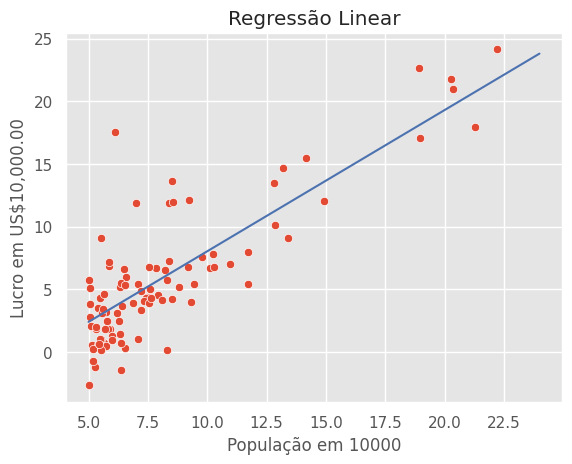

In [ ]:
sns.scatterplot(x="Population", y="Profit", data=data)
x_value = [x for x in range(5,25)]
y_value = [(x*theta[1]+theta[0]) for x in x_value]
plt.plot(x_value,y_value,'b-')
plt.xlabel("População em 10000")
plt.ylabel("Lucro em US$10,000.00")
plt.title("Regressão Linear")

Usaremos a função:

In [ ]:
def predict(x,theta):
    xx = np.array([1,x])
    y_pred = xx @ theta
    return round(y_pred.item(),4)

Com $\theta$ já calculado podemos definir a função que faz as predições para o lucro

$$
h_{\theta}(x) = \theta^T x
$$

Por exemplo,

In [ ]:
y_pred1 = predict(20,theta)*10000

print("Predição de lucro para uma população de 200 mil habitantes: US$" +str(round(y_pred1,2)))

Predição de lucro para uma população de 200 mil habitantes: US$193045.0


In [ ]:
y_pred2 = predict(8.4,theta)*10000
print("Predição de lucro para uma população de 84000 habitantes: US$" +str(round(y_pred2,2)))

Predição de lucro para uma população de 84000 habitantes: US$62279.0


### scikit-learn

A biblioteca `scikit-learn` oferece a classe `LinearRegression` para realizar **regressão linear por mínimos quadrados ordinários**. Ela ajusta um modelo linear escolhendo os coeficientes que minimizam a **soma dos quadrados dos resíduos** entre os valores observados e os valores previstos. Depois do ajuste, os parâmetros do modelo ficam disponíveis nos atributos `coef_` e `intercept_`.

O fluxo de uso é simples:

1. organizar os dados de entrada `X` e de saída `y`;
2. criar o modelo;
3. ajustar o modelo com `fit(X, y)`;
4. obter previsões com `predict(X)`;
5. avaliar o ajuste, por exemplo com `score(X, y)`, que no caso da regressão linear retorna o coeficiente de determinação \(R^2\).

Vejamos  exemplos:

#### Exemplo 7.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# dados
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

# o sklearn espera X no formato de matriz coluna
X = x.reshape(-1, 1)

# cria o modelo
modelo = LinearRegression()

# ajusta o modelo aos dados
modelo.fit(X, y)

# coeficientes da reta y = a + bx
a = modelo.intercept_
b = modelo.coef_[0]

print("intercepto =", a)
print("inclinação =", b)


intercepto = 1.7999999999999998
inclinação = 0.8000000000000002


In [ ]:
# previsões
y_pred = modelo.predict(X)
print("valores previstos =", y_pred)

valores previstos = [2.6 3.4 4.2 5.  5.8]


In [ ]:
# coeficiente de determinação
r2 = modelo.score(X, y)
print("R^2 =", r2)

R^2 = 0.7272727272727274


#### Exemplo 8
Uma empresa de energia deseja prever a demanda de eletricidade (em megawatts, MW) com base na temperatura externa (em °C). Ela coletou dados de uma rede elétrica durante vários dias.

Espera-se que a relação seja não linear em geral (por exemplo, temperaturas muito altas ou muito baixas aumentam a demanda devido ao aquecimento/resfriamento), mas para uma faixa moderada, uma aproximação linear é razoável.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Dados temperatura (°C) vs demanda de energia elétrica (MW)
temperature = np.array([10, 12, 15, 17, 20, 22, 24, 25, 26, 27, 29, 30]).reshape(-1, 1)
demand = np.array([520, 510, 490, 480, 460, 455, 450, 448, 447, 446, 445, 444])  # MW

Façamos o gráfico dos dados:

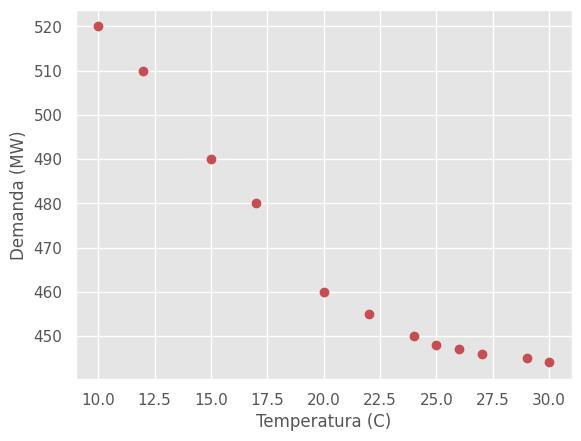

In [ ]:
plt.plot(temperature,demand,'ro')
plt.xlabel('Temperatura (C)')
plt.ylabel('Demanda (MW)')
plt.grid(True)
plt.show()

Usaremos o comando do módulo para fazer o ajuste:

In [ ]:
# Ajuste
model = LinearRegression()
model.fit(temperature, demand)
pred = model.predict(temperature)
r2 = r2_score(demand, pred)

In [ ]:
# Coeficientes
print(f'Intercepto (demanda de base): {model.intercept_:.2f} MW')
print(f'Inclinação (taxa por °C): {model.coef_[0]:.2f} MW/°C')
print(f'r²: {r2:.4f}')

Intercepto (demanda de base): 550.04 MW
Inclinação (taxa por °C): -3.91 MW/°C
r²: 0.9225


Os resultados indicam que 92,25% da incerteza original foi explicada por esse modelo. Esse resultado confirma a conclusão de que a equação quadrática representa um bom ajuste, como também é evidente a partir do gráfico.

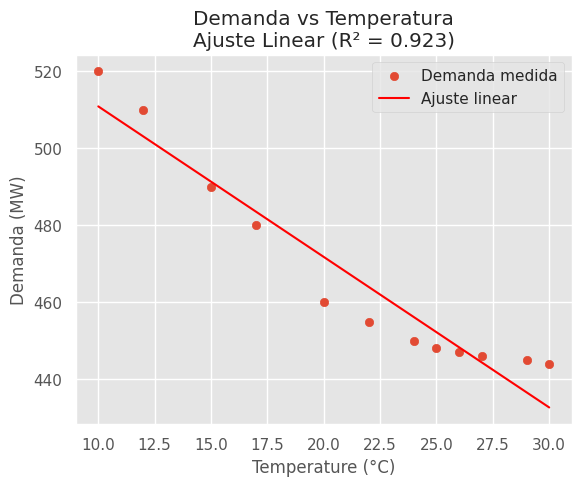

In [ ]:
plt.scatter(temperature, demand, label='Demanda medida')
plt.plot(temperature, pred, color='red', label='Ajuste linear')
plt.xlabel('Temperature (°C)')
plt.ylabel('Demanda (MW)')
plt.title(f'Demanda vs Temperatura\nAjuste Linear (R² = {r2:.3f})')
plt.legend()
plt.grid(True)
plt.show()

Façamos um predição de demanda quando a temperatura é de 16°C.

In [ ]:
# T_new = pd.DataFrame({'Temperature': [16]})
demand_pred = model.predict([[16]])
print(f'Demanda prevista a 16°C: {demand_pred[0]:.2f} MW')

Demanda prevista a 16°C: 487.44 MW


Os dados apararentemente não se ajustam tão bem a uma reta. Façamos um ajuste quadrático usando inicialmente o método do Scipy para mínimos quadrados.

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# Dados
x = np.array([10, 12, 15, 17, 20, 22, 24, 25, 26, 27, 29, 30])
y = np.array([520, 510, 490, 480, 460, 455, 450, 448, 447, 446, 445, 444])  # MW

# Modelo
def h(t, a, b, c):
    return a + b*t + c*t**2

# Ajuste da curva
param, pcov = curve_fit(h, x, y)

Text(0, 0.5, 'Demanda (MW)')

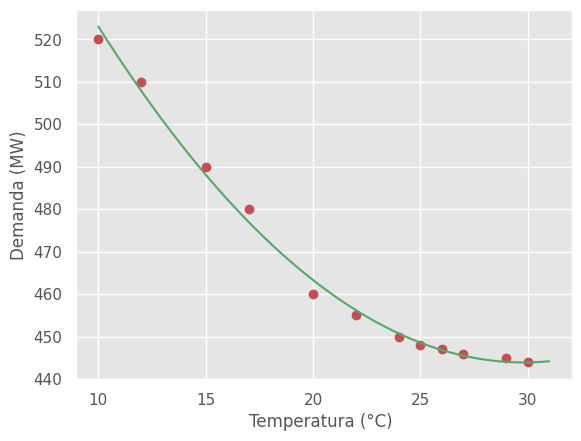

In [ ]:
t = np.linspace(10, 31,50)
plt.plot(x,y,'ro', t, h(t, *param), 'g-')
plt.xlabel('Temperatura (°C) ')
plt.ylabel('Demanda (MW)')

O coeficiente de determinação é dado por:

In [ ]:
y_pred = h(x, *param)
y_mean = np.mean(y)
ss_total = np.sum((y - y_mean)**2)
ss_res = np.sum((y - y_pred)**2)

r2 = 1 - ss_res / ss_total

print(f"r²= {r2:.4f}")

r²= 0.9949


Os resultados indicam que 99,49% da incerteza original foi explicada por esse modelo. Esse resultado confirma a conclusão de que a equação quadrática representa um ajuste melhor do que o linear, como também é evidente a partir do gráfico.

Os coeficientes do polinômio são:

In [ ]:
param

array([ 6.22982806e+02, -1.20137427e+01,  2.01492435e-01])

Podemos imprimir o polinômio resultante:

In [ ]:
a, b, c = param

print(f"Função ajustada:")
print(f"h(t) = {a:.4f} + {b:.4f}t + {c:.4f}t**2")

Função ajustada:
h(t) = 622.9828 + -12.0137t + 0.2015t**2


#### Exemplo 9

Tomemos agora um conjunto de dados com diversas variáveis. O California Housing Dataset é um conjunto de dados amplamente utilizado em projetos de aprendizado de máquina, especialmente para tarefas de regressão. Ele foi derivado do Censo dos Estados Unidos de 1990 e contém informações sobre características demográficas e habitacionais de diferentes regiões da Califórnia. Temos:

- Número de amostras: 20.640

- Número de atributos: 8 variáveis preditoras numéricas e 1 variável alvo

- Variável alvo: MedHouseVal – Valor mediano das casas em unidades de US$100.000

Descrição das Variáveis:

- MedInc: Renda mediana dos habitantes no grupo de blocos (em dezenas de milhares de dólares).

- HouseAge: Idade mediana das casas no grupo de blocos.

- AveRooms: Média do número de cômodos por residência.

- AveBedrms: Média do número de quartos por residência.

- Population: População total do grupo de blocos.

- AveOccup: Média de ocupantes por residência.

- Latitude: Latitude geográfica do grupo de blocos.

- Longitude: Longitude geográfica do grupo de blocos.

- MedHouseVal: Valor mediano das casas no grupo de blocos (em centenas de milhares de dólares).

Nosso objetivo aqui é utilizar regressão linear  para prever o valor médio das casas (MedHouseVal) com base na **mediana de renda** (MedInc). Como o número de dados é muito grande (2640 para cada variável), usaremos gradientes descendentes.

Para futura comparação usaremos a função baseada em gradientes descendentes , definida previamente:

In [ ]:
def grad2(x, y):
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    alpha = 0.04
    n_it = 10000
    m = len(x)
    theta = np.zeros((2,1))
    X = np.c_[np.ones((m, 1)), x]
    for _ in range(n_it):
        gradJ = 1/m * X.T @ (X @ theta - y)
        theta = theta - alpha * gradJ
    return theta

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
# Carregar o California Housing Dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

Podemos fazer obter um sumário de todo o dataset:

In [ ]:
# Summary statistics
summary = df.describe()
print(summary)

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Definimos os valores de interesse:

In [ ]:
X = df[['MedInc']].values
y = df['MedHouseVal'].values

Note que, de acordo com a definição acima,

In [ ]:
np.shape(X)

(20640, 1)

In [ ]:
np.shape(y)

(20640,)

Examinemos os dados graficamente:

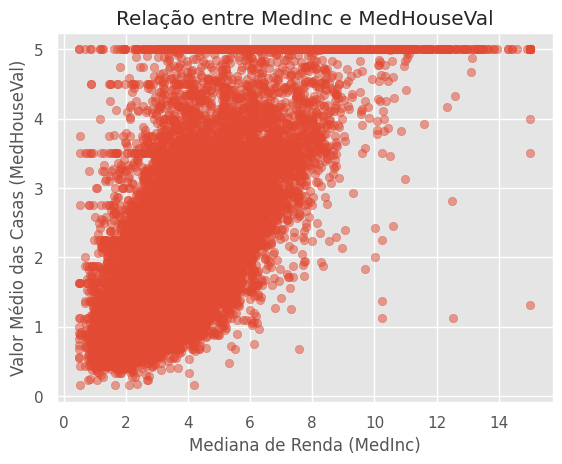

In [ ]:
plt.scatter(X, y, alpha=0.5)
plt.xlabel('Mediana de Renda (MedInc)')
plt.ylabel('Valor Médio das Casas (MedHouseVal)')
plt.title('Relação entre MedInc e MedHouseVal')
plt.show()

Inicialmente usemos nossa função:

In [ ]:
theta = grad2(X,y)
theta

array([[0.45085577],
       [0.41793849]])

In [ ]:
theta = np.squeeze(theta)

Façamos o gráfico da reta de regressão:

Text(0.5, 1.0, 'Regressão Linear')

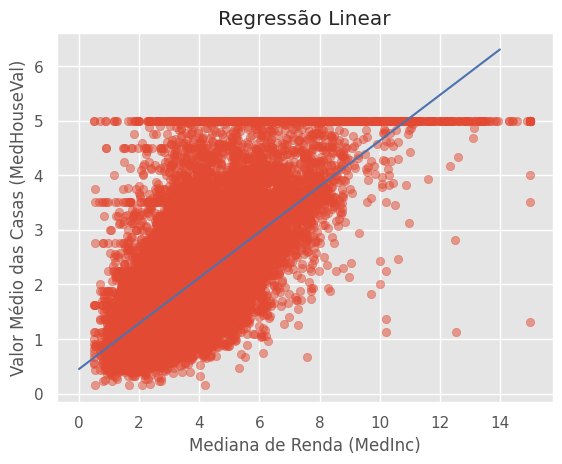

In [ ]:
x_value = [x for x in range(0,15)]
y_value = [(x*theta[1]+theta[0]) for x in x_value]
plt.plot(x_value,y_value,'b-')
plt.scatter(X, y, alpha=0.5)
plt.xlabel('Mediana de Renda (MedInc)')
plt.ylabel('Valor Médio das Casas (MedHouseVal)')
plt.title('Relação entre MedInc e MedHouseVal')
plt.title("Regressão Linear")

Usemos agora os comandos do módulo sklearn:

In [ ]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

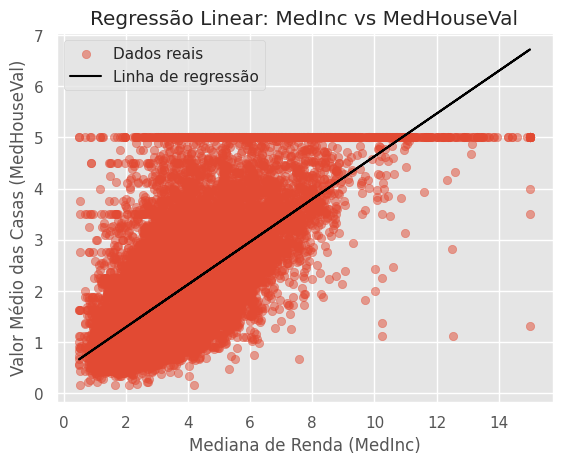

In [ ]:
plt.scatter(X, y, alpha=0.5, label='Dados reais')
plt.plot(X, y_pred, color='black', label='Linha de regressão')
plt.xlabel('Mediana de Renda (MedInc)')
plt.ylabel('Valor Médio das Casas (MedHouseVal)')
plt.title('Regressão Linear: MedInc vs MedHouseVal')
plt.legend()
plt.show()

Podemos ver que os coeficientes da reta de regressão são similares àqueles que obtivemos anteriormente:

In [ ]:
# Coeficiente angular (inclinação)
b = model.coef_[0]
print(b)
# Coeficiente linear (intercept)
a = model.intercept_
print(a)

0.41793849201896277
0.45085576703267893


In [ ]:
r2 = r2_score(y, y_pred)
print(f"Coeficiente de determinação (r²): {r2:.4f}")

Coeficiente de determinação (r²): 0.4734


Podemos concluir que temos:

- Moderado poder explicativo: O modelo consegue explicar cerca de metade da variabilidade observada nos dados, o que pode ser considerado um ajuste moderado.

- Variabilidade não explicada: Cerca de 47.34% da variabilidade permanece não explicada pelo modelo, sugerindo que outros fatores influenciam significativamente a variável dependente.

#### Exemplo 10
Mostraremos agora como usar o módulo sklearn (scikit-learn), num exemplo que envolve a previsão do número de seguidores com base em horas na rede social. Inicialmente importamos as bibliotecas:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Suponha que temos os seguintes dados de usuários:

In [ ]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)

# Número de seguidores (variável dependente)
y = np.array([100, 130, 200, 250, 310, 350, 430, 430, 509, 520])

Notemos acima que ao usar essa  biblioteca, a variável independente sempre deverá convertida para uma matriz coluna (que denotaremos por um letra maiúscula), enquanto que a variável dependente permanece um 1-array (letra minúscula):

In [ ]:
np.shape(X)

(10, 1)

In [ ]:
np.shape(y)

(10,)

O jargão comum na regressão linear deriva de sua já clássica aplicação, que é aprendizado de máquina. Falamos em criar e treinar o modelo:

In [ ]:
# Criamos o modelo de regressão linear
modelo = LinearRegression()

# Treinar o modelo com os dados
modelo.fit(X, y)

LinearRegression()

Podemos agora obter os coeficientes da reta de regressão

In [ ]:
# Coeficiente angular (inclinação da reta)
coef_angular = modelo.coef_[0]

# Coeficiente linear (intercepto)
coef_linear = modelo.intercept_

# Coeficiente de determinação
y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)

print(f'Coeficiente angular (inclinação): {coef_angular:.2f}')
print(f'Coeficiente linear (intercepto): {coef_linear:.2f}')
print(f"Coeficiente de determinação (r²): {r2:.4f}")

Coeficiente angular (inclinação): 49.47
Coeficiente linear (intercepto): 50.80
Coeficiente de determinação (r²): 0.9867


Os resultados indicam que 98,67% da incerteza original foi explicada por esse modelo. Esse resultado confirma a conclusão de que a equação quadrática representa um bom ajuste, como também é evidente a partir do gráfico. Visualizemos os resultados:

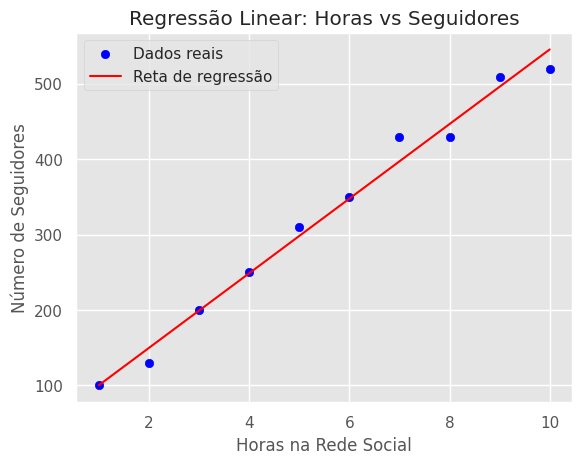

In [ ]:
# Plotar os dados e a linha de regressão
plt.scatter(X, y, color='blue', label='Dados reais')
plt.plot(X, y_pred, color='red', label='Reta de regressão')
plt.xlabel('Horas na Rede Social')
plt.ylabel('Número de Seguidores')
plt.title('Regressão Linear: Horas vs Seguidores')
plt.legend()
plt.grid(True)
plt.show()

Façamos previsões para alguns casos:

In [ ]:
# Prever o número de seguidores para 11 horas
horas = np.array([[11], [15]])
seguidores_previstos = modelo.predict(horas)

print(f'Número previsto de seguidores para 11 horas: {seguidores_previstos[0]:.0f}')
print(f'Número previsto de seguidores para 15 horas: {seguidores_previstos[1]:.0f}')

Número previsto de seguidores para 11 horas: 595
Número previsto de seguidores para 15 horas: 793


In [ ]:
np.shape(horas)

(2, 1)

### Regressão linear multivariada

#### **Exemplo 11**
O arquivo Advertising.csv contém um conjunto de dados clássico usado para ilustrar modelos de regressão linear em problemas de previsão de vendas com base em investimentos publicitários. Ele aparece, em [2]. O Advertising Dataset contém informações sobre os investimentos em publicidade em três canais de mídia — TV, Rádio e Jornal — e as respectivas vendas de um produto em diferentes mercados. Cada linha representa dados de um mercado específico.

- TV: Investimento em publicidade na TV (em milhares de dólares).

- Radio: Investimento em publicidade no rádio (em milhares de dólares).

- Newspaper: Investimento em publicidade em jornais (em milhares de dólares).

- Sales: Vendas do produto (em milhares de unidades).

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [18]:
# Carregar o dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
df = pd.read_csv(url)

Examinemos os dados desse dataset:

In [19]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Aqui está o sumário estatístico desse dataset:

In [20]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


Notemos que a coluna 'Unnamed: 0' é apenas um índice e pode ser descartada. Façamos inicialmente uma análise univariada, usando somente anúncios em TV (variável independente) e sales com variável dependente:

In [21]:
# Selecionamos as variáveis
X = df[['TV']]  # Variável independente
y = df['sales']  # Variável dependente


In [22]:
# Criamos e ajustamos o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X, y)
# Fazemos previsões
y_pred = modelo.predict(X)

# Coeficientes do modelo
coef_angular = modelo.coef_[0]
coef_linear = modelo.intercept_
r2 = r2_score(y, y_pred)

In [23]:
# Exibimos os resultados
print(f'Coeficiente angular (inclinação): {coef_angular:.4f}')
print(f'Coeficiente linear (intercepto): {coef_linear:.4f}')
print(f'Coeficiente de determinação  (r²): {r2:.4f}')

Coeficiente angular (inclinação): 0.0475
Coeficiente linear (intercepto): 7.0326
Coeficiente de determinação  (r²): 0.6119


Portanto, aproximadamente 61.19 % da variabilidade nas vendas é explicada pelos investimentos em publicidade em TV. Vejamos o gráfico correspondente:

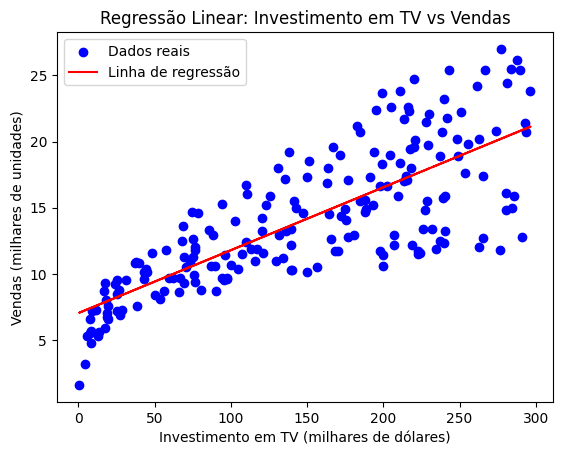

In [24]:
# Visualizamos os dados e a linha de regressão
plt.scatter(X, y, color='blue', label='Dados reais')
plt.plot(X, y_pred, color='red', label='Linha de regressão')
plt.xlabel('Investimento em TV (milhares de dólares)')
plt.ylabel('Vendas (milhares de unidades)')
plt.title('Regressão Linear: Investimento em TV vs Vendas')
plt.legend()
plt.show()

Suponhamos que queremos prever as vendas para um investimento de 180 mil e 120 mil dólares em TV:

In [25]:
# Prevemos o valor de vendas para um investimento de US 180000 em TV
x_novo = pd.DataFrame({'TV': [180,120]})
y_novo = modelo.predict(x_novo)

print(f'Previsão de vendas para investimento de 180 mil: {y_novo[0]:.2f} mil unidades')
print(f'Previsão de vendas para investimento de 120 mil: {y_novo[1]:.2f} mil unidades')

Previsão de vendas para investimento de 180 mil: 15.59 mil unidades
Previsão de vendas para investimento de 120 mil: 12.74 mil unidades


In [26]:
x_novo

,TV
0,180
1,120


#### Exemplo 11
Vamos realizar uma regressão linear múltipla utilizando o Advertising Dataset para prever as vendas com base nos investimentos em publicidade em TV, Rádio e Jornal. Primeiro, carregamos o dataset e verificamos suas primeiras entradas para entender sua estrutura.

In [27]:
import pandas as pd

# Carregamos o dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
df = pd.read_csv(url)

# Exibir as primeiras linhas do dataset
print(df.head())

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


Novamente,  a coluna 'Unnamed: 0' é apenas um índice e pode ser descartada. Selecionamos as variáveis independentes (TV, radio, newspaper) e a variável dependente (sales):

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Definimos variáveis independentes e dependente
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

Criamos e ajustamos o modelo aos dados.

In [29]:
# Criamos o modelo de regressão linear
modelo = LinearRegression()

# Ajustar o modelo aos dados
modelo.fit(X, y)

LinearRegression()

Avaliamos o desempenho do modelo utilizando o coeficiente de determinação

In [30]:
# Fazemos previsões
y_pred = modelo.predict(X)

# Coeficientes do modelo
coeficientes = modelo.coef_
intercepto = modelo.intercept_

# Coeficiente de determinação R²
r2 = r2_score(y, y_pred)

# Exibir os resultados
print(f'Intercepto: {intercepto:.4f}')
print(f'Coeficientes: {coeficientes}')
print(f'Coeficiente de determinação (R²): {r2:.4f}')

Intercepto: 2.9389
Coeficientes: [ 0.04576465  0.18853002 -0.00103749]
Coeficiente de determinação (R²): 0.8972


Portanto, aproximadamente 89.72% da variabilidade nas vendas é explicada pelos investimentos em publicidade nos três canais.

Suponhamos que queremos prever as vendas para os seguintes investimentos:

- TV: 150 mil dólares
- Rádio: 22 mil dólares
- Jornal: 12 mil dólares

In [31]:
# Novo conjunto de dados para previsão (como DataFrame com nomes de colunas)
novo_investimento = pd.DataFrame([[150, 22, 12]], columns=['TV', 'radio', 'newspaper'])

# Previsão de vendas
venda_prevista = modelo.predict(novo_investimento)

print(f"Vendas previstas: {venda_prevista[0]:.2f} mil unidades")

Vendas previstas: 13.94 mil unidades


Podemos testar múltiplos conjuntos de dados de investimento:

In [32]:
# Múltiplos conjuntos de dados para previsão (com nomes de colunas)
novos_investimentos = pd.DataFrame([
    [150, 22, 12],
    [200, 30, 20],
    [100, 15, 10]
], columns=['TV', 'radio', 'newspaper'])

# Previsões de vendas
vendas_previstas = modelo.predict(novos_investimentos)

for i, pred in enumerate(vendas_previstas):
    print(f"Conjunto {i+1}: Vendas previstas = {pred:.2f} mil unidades")


Conjunto 1: Vendas previstas = 13.94 mil unidades
Conjunto 2: Vendas previstas = 17.73 mil unidades
Conjunto 3: Vendas previstas = 10.33 mil unidades


Podemos visualizar a relação entre as variáveis independentes e a variável dependente utilizando gráficos de dispersão:

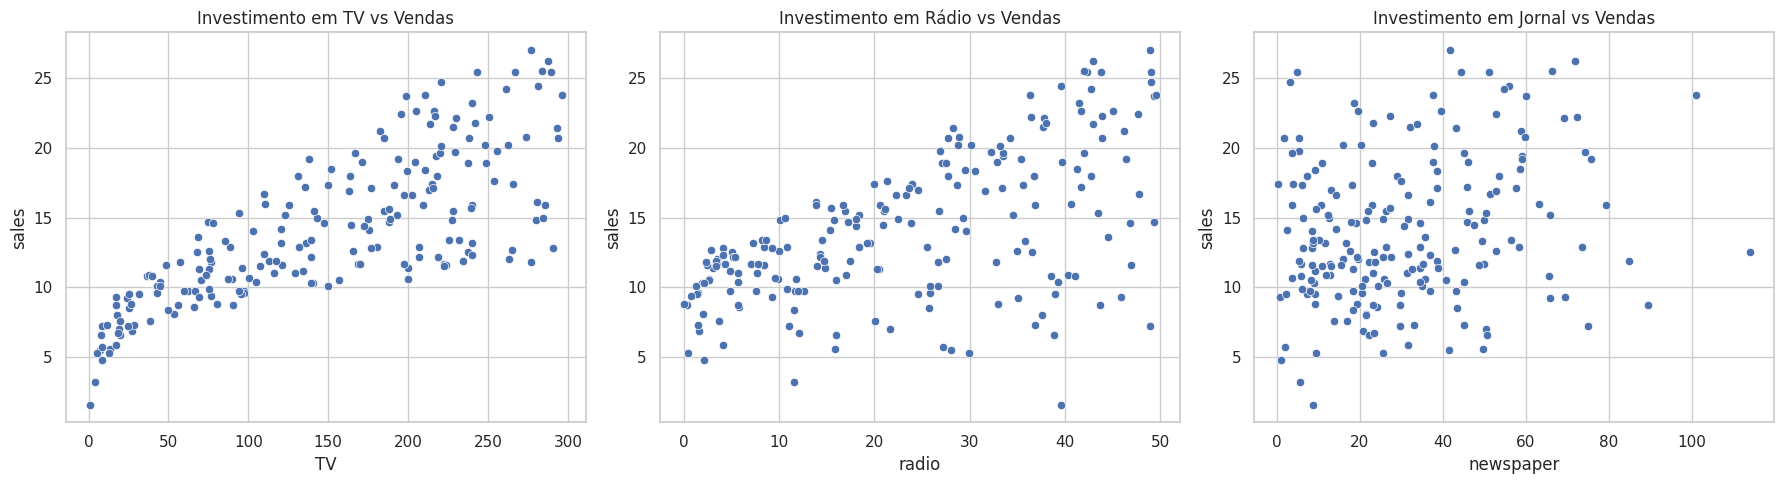

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos o estilo dos gráficos
sns.set(style="whitegrid")

# Criamos gráficos de dispersão para cada variável independente
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='TV', y='sales', data=df, ax=axs[0])
axs[0].set_title('Investimento em TV vs Vendas')

sns.scatterplot(x='radio', y='sales', data=df, ax=axs[1])
axs[1].set_title('Investimento em Rádio vs Vendas')

sns.scatterplot(x='newspaper', y='sales', data=df, ax=axs[2])
axs[2].set_title('Investimento em Jornal vs Vendas')

plt.tight_layout()
plt.show()

Vemos que investimentos em TV e Rádio têm impactos significativos nas vendas, enquanto o investimento em Jornal não apresenta uma contribuição relevante.

#### **Exemplo 12**

O conjunto de dados Auto MPG é um recurso clássico amplamente utilizado em projetos de aprendizado de máquina, especialmente para tarefas de regressão. Ele está disponível no UCI Machine Learning Repository e contém especificações técnicas de automóveis fabricados entre 1970 e 1982.

*Descrição do Conjunto de Dados*

Objetivo: Prever o consumo de combustível de um carro, medido em milhas por galão (MPG), com base em suas características técnicas.

**Tamanho:**  398 registros.

**Atributos:**

- mpg: Consumo de combustível (milhas por galão) — variável alvo contínua.

- cylinders: Número de cilindros do motor — variável discreta.

- displacement: Deslocamento do motor (polegadas cúbicas) — contínua.

- horsepower: Potência do motor — contínua (contém valores ausentes representados por '?').

- weight: Peso do veículo (libras) — contínua.

- acceleration: Tempo para acelerar de 0 a 60 mph (segundos) — contínua.

- model_year: Ano do modelo do carro (70 para 1970, etc.) — discreta.

- origin: Origem do carro (1: EUA, 2: Europa, 3: Japão) — categórica.

- car_name: Nome do modelo do carro — cadeia de caracteres única para cada instância.

Faremos um regressão linear multivariada para descrever o consumo (mpg) em termos das 5 variáveis numéricas cylinders,	displacement,	horsepower,	weight,	acceleration. Para isso usaremos o módulo sklearn.

In [51]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
import os


Os dados podem ser carregados a partir de um domíno público:

In [52]:
path = kagglehub.dataset_download("uciml/autompg-dataset")

arquivo = os.path.join(path, "auto-mpg.csv")
df = pd.read_csv(arquivo)

print(df.head())

Using Colab cache for faster access to the 'autompg-dataset' dataset.
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


Façamos um breve exame do dataset:

In [53]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [54]:
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object


Devemos converter algumas variáveis acima de texto para numéricas.Façamos agora o processamento dos dados a serem usados:

In [55]:
# Substitui "?" por NaN
df = df.replace("?", np.nan)

# Converte colunas numéricas que podem ter sido lidas como texto
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna()

# Remove a coluna de nome do carro
df = df.drop("car name", axis=1)

# Define variáveis explicativas e variável alvo
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]
X = df[features].values
y = df["mpg"].values

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
print(X_scaled[:5])

[[ 1.48394702  1.07728956  0.66413273  0.62054034 -1.285258  ]
 [ 1.48394702  1.48873169  1.57459447  0.84333403 -1.46672362]
 [ 1.48394702  1.1825422   1.18439658  0.54038176 -1.64818924]
 [ 1.48394702  1.04858429  1.18439658  0.53684535 -1.285258  ]
 [ 1.48394702  1.02944745  0.92426466  0.5557062  -1.82965485]]


In [57]:
# Inicializamos e ajusta o modelo de regressão linear
model = LinearRegression()
model.fit(X_scaled, y)

LinearRegression()

In [58]:
# Previsões
y_pred = model.predict(X_scaled)

In [59]:
# Coeficiente de determinação
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
r2

0.7076926326770515

In [60]:
# Resultados
print("Coeficientes:", model.coef_)
print("coeficiente linear:", model.intercept_)
print("Erro quadrático médio:", mse)
print("Coeficiente de determinação:", r2)

Coeficientes: [-0.67791319 -0.00868797 -1.73977416 -4.40015767 -0.08019347]
coeficiente linear: 23.445918367346938
Erro quadrático médio: 17.76139610540622
Coeficiente de determinação: 0.7076926326770515


Façamos um gráfico que mostra os valores observados e previstos de consumo (MPG):

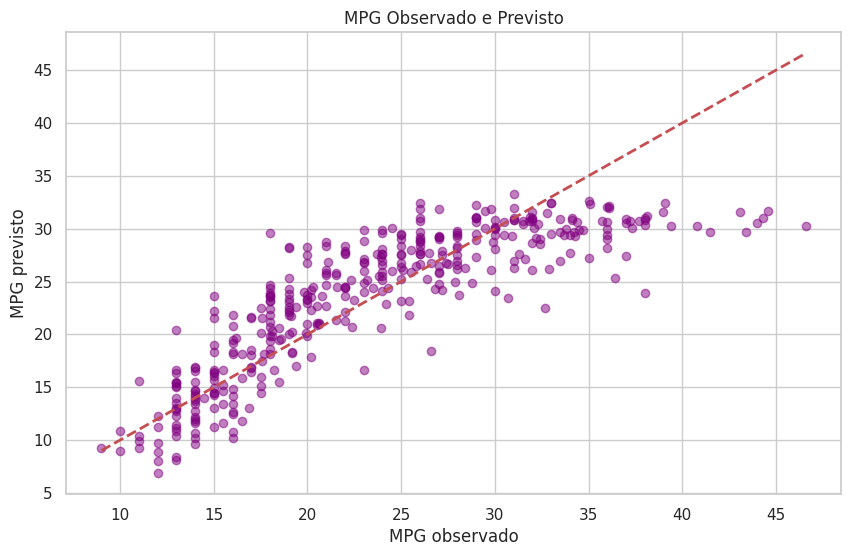

In [61]:
# Visualizamos MPG observado e previsto
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='purple', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('MPG observado')
plt.ylabel('MPG previsto')
plt.title('MPG Observado e Previsto')
plt.savefig('auto_mpg_plot.png')

Notemos que:

- Pontos próximos à linha vermelha indicam previsões precisas do modelo.
- Pontos distantes da linha sugerem erros maiores na previsão.
- A dispersão dos pontos ao redor da linha pode indicar a variabilidade dos erros e possíveis padrões não capturados pelo modelo.

Podemos examinar a equação do hiperplano ajustado:

In [62]:
# Equação do hiperplano
print("\nEquação do hiperplano:")
equation = f"MPG = {model.intercept_:.4f}"
for i, (coef, feature) in enumerate(zip(model.coef_, features)):
    equation += f" + ({coef:.4f})(standardized {feature})"
print(equation)


Equação do hiperplano:
MPG = 23.4459 + (-0.6779)(standardized cylinders) + (-0.0087)(standardized displacement) + (-1.7398)(standardized horsepower) + (-4.4002)(standardized weight) + (-0.0802)(standardized acceleration)


Façamos algumas previsões:

In [63]:
# Formato: [cylinders, displacement, horsepower, weight, acceleration]
example_cars = [
    [4, 120.0, 80.0, 2000.0, 18.0],  # Small efficient car
    [6, 200.0, 100.0, 3000.0, 15.0],  # Mid-range car
    [8, 350.0, 150.0, 4000.0, 12.0]   # Heavy less-efficient car
]

# Convertemos para 1-array
example_cars = np.array(example_cars)

# Padronizamos os valores dos recursos de exemplo usando o mesmo escalador
example_cars_scaled = scaler.transform(example_cars)

# Prevemos MPG para os conjuntos de exemplo
predictions = model.predict(example_cars_scaled)

# Imprimimos as previsões
print("\nExemplos de predições:")
for i, (car, pred) in enumerate(zip(example_cars, predictions)):
    print(f"\nCar {i+1}:")
    for feature, value in zip(features, car):
        print(f"  {feature}: {value}")
    print(f"  MPG previsto: {pred:.2f}")


Exemplos de predições:

Car 1:
  cylinders: 4.0
  displacement: 120.0
  horsepower: 80.0
  weight: 2000.0
  acceleration: 18.0
  MPG previsto: 30.14

Car 2:
  cylinders: 6.0
  displacement: 200.0
  horsepower: 100.0
  weight: 3000.0
  acceleration: 15.0
  MPG previsto: 23.34

Car 3:
  cylinders: 8.0
  displacement: 350.0
  horsepower: 150.0
  weight: 4000.0
  acceleration: 12.0
  MPG previsto: 15.17


Façamos um estudo de correlação entre MPG e cada uma das variáveis, calculando o coeficiente de correlação entre cada par:

In [64]:
# Coeficiente de Pearson
print("\nCoeficiente de correlação de Pearson entre MPG e Features:")
correlations = df[features + ['mpg']].corr()['mpg'].drop('mpg')
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.4f}")


Coeficiente de correlação de Pearson entre MPG e Features:
cylinders: -0.7776
displacement: -0.8051
horsepower: -0.7784
weight: -0.8322
acceleration: 0.4233


Visualisemos graficamente a correlação entre MPG e variáveis explicativas:

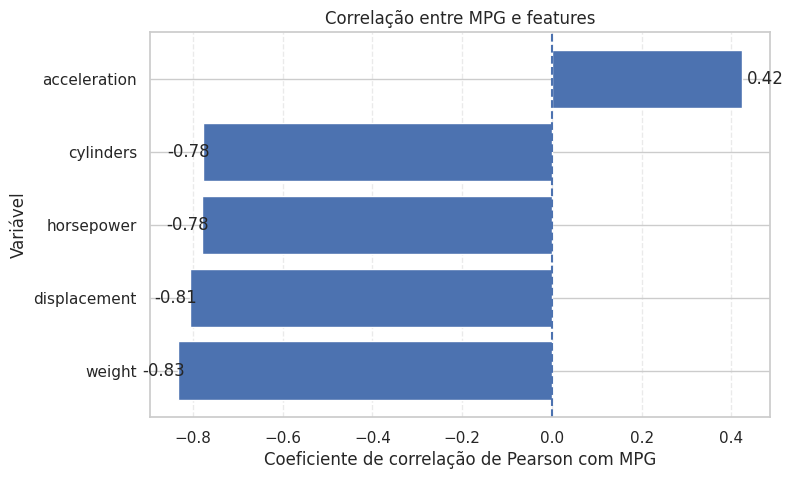

In [65]:
import matplotlib.pyplot as plt
import numpy as np

correlations = df[features + ['mpg']].corr()['mpg'].drop('mpg')
correlations = correlations.sort_values()

plt.figure(figsize=(8, 5))
plt.barh(correlations.index, correlations.values)

for i, v in enumerate(correlations.values):
    plt.text(v + 0.01 if v >= 0 else v - 0.08, i, f"{v:.2f}", va='center')

plt.axvline(0, linestyle='--')
plt.xlabel("Coeficiente de correlação de Pearson com MPG")
plt.ylabel("Variável")
plt.title("Correlação entre MPG e features")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

Mostramos agora a matriz de correlação:

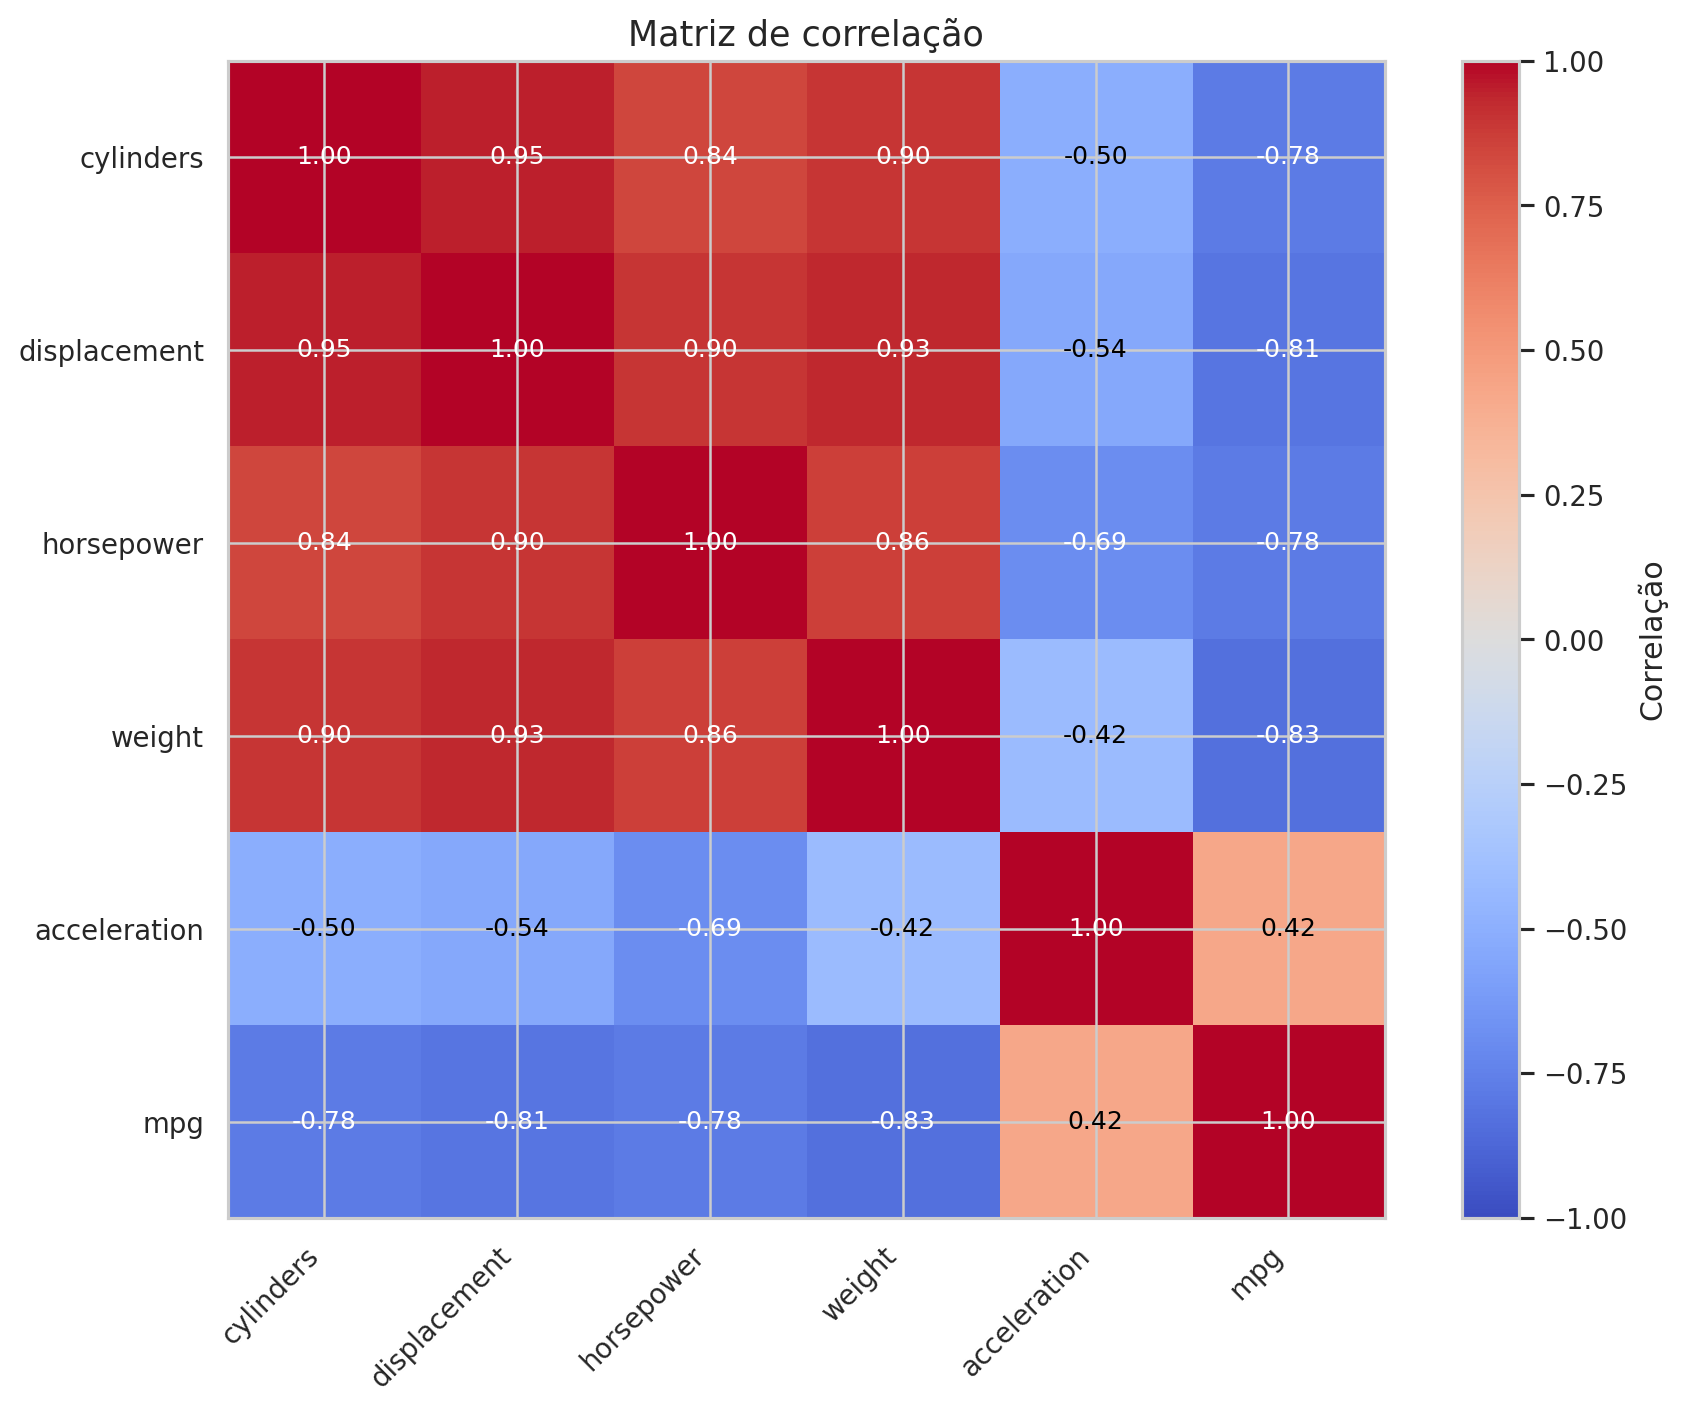

In [66]:
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = df[features + ['mpg']].corr()

plt.figure(figsize=(10, 8), dpi=180)
plt.imshow(corr_matrix, interpolation='nearest', cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlação")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right',
    fontsize=11
)
plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index,
    fontsize=11
)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        valor = corr_matrix.iloc[i, j]
        cor_texto = "white" if abs(valor) > 0.6 else "black"
        plt.text(
            j, i,
            f"{valor:.2f}",
            ha='center',
            va='center',
            fontsize=10,
            color=cor_texto
        )

plt.title("Matriz de correlação", fontsize=14)
plt.tight_layout()
plt.show()

Façamos um resumo do programa em uma única célula:

In [67]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
import os

# Baixa o dataset
path = kagglehub.dataset_download("uciml/autompg-dataset")

# Lê o arquivo
arquivo = os.path.join(path, "auto-mpg.csv")
df = pd.read_csv(arquivo)

# Limpeza dos dados
df = df.replace("?", np.nan)
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna()

# Remove a coluna não numérica
df = df.drop("car name", axis=1)

# Define variáveis explicativas e variável resposta
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]
X = df[features].values
y = df["mpg"].values

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajuste do modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X_scaled, y)

# Previsões
y_pred = modelo.predict(X_scaled)

# Métricas
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)
print("Erro quadrático médio (MSE):", mse)
print("Coeficiente de determinação (R²):", r2)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Intercepto: 23.445918367346938
Coeficientes: [-0.67791319 -0.00868797 -1.73977416 -4.40015767 -0.08019347]
Erro quadrático médio (MSE): 17.76139610540622
Coeficiente de determinação (R²): 0.7076926326770515


### Divisão Treino/Teste em Aprendizado de Máquina

No aprendizado de máquina, a divisão dos dados em conjuntos de **treino** e **teste** é uma prática fundamental para avaliar o desempenho de um modelo preditivo. O objetivo é garantir que o modelo não apenas se ajuste bem aos dados usados para seu treinamento, mas também generalize para dados novos e não vistos. Esta seção explica a teoria por trás dessa divisão, destacando sua importância e considerações práticas.

A divisão treino/teste consiste em separar o conjunto de dados disponível em duas partes:

- **Conjunto de treino**: Usado para ajustar o modelo, ou seja, para estimar os parâmetros do modelo (por exemplo, coeficientes em uma regressão linear).
- **Conjunto de teste**: Usado para avaliar o desempenho do modelo em dados não utilizados durante o treinamento, simulando sua performance em aplicações reais.

Seja $ D = \{(x_i, y_i)\}_{i=1}^N $ o conjunto de dados com $  N $ amostras, onde $ x_i $ são as variáveis preditoras e $ y_i $ é a variável alvo. A divisão treino/teste particiona $ D $ em:

- $ D_{\text{treino}}$, com $ N_{\text{treino}} $ amostras (geralmente 70%–80% de $ N $).
- $ D_{\text{teste}}$, com $ N_{\text{teste}} $ amostras (geralmente 20%–30% de $ N $).

A divisão é feita de forma aleatória, mas pode ser estratificada para manter a proporção de classes (em problemas de classificação) ou valores (em regressão).

O objetivo principal da divisão é avaliar a **generalização** do modelo. Um modelo que apresenta bom desempenho no conjunto de treino, mas desempenho ruim no conjunto de teste, sofre de *overfitting* (sobreajuste), ou seja, ele memorizou os dados de treino em vez de aprender padrões gerais. Por outro lado, um modelo com desempenho ruim em ambos os conjuntos pode estar subajustado (*underfitting*), indicando que é muito simples ou mal configurado.

O desempenho do modelo é medido usando métricas como:

- **Erro Quadrático Médio (MSE)** para regressão:
  $$
  \text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2,
  $$
  onde $ \hat{y}_i $ é a previsão do modelo.
  
- **Coeficiente de Determinação ($ r^2 $)**: Mede a proporção da variância explicada pelo modelo.

Comparamos essas métricas no conjunto de treino e no conjunto de teste. Idealmente, o MSE no teste deve ser próximo ao do treino, e o$r^2 $ deve ser alto em ambos.

Notas:

- **Tamanho da divisão**: Uma proporção comum é 80% treino e 20% teste, mas isso depende do tamanho do conjunto de dados. Conjuntos pequenos podem exigir validação cruzada em vez de uma única divisão.
- **Aleatoriedade**: A divisão deve ser aleatória para evitar viés, mas fixar uma semente (*random seed*) garante reprodutibilidade.
- **Vazamento de dados**: O conjunto de teste deve ser completamente isolado durante o treinamento. Por exemplo, a padronização de dados deve usar apenas as estatísticas (média e desvio padrão) do conjunto de treino.


#### **Exemplo 13**
Consideremos um exemplo puramente numérico.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# Definir semente aleatória para reprodutibilidade
np.random.seed(42)

In [ ]:
# Geramos dados simulados
n_samples = 100
X1 = np.random.uniform(0, 10, n_samples)  # Variável 1
X2 = np.random.uniform(0, 10, n_samples)  # Variável 2
X3 = np.random.uniform(0, 10, n_samples)  # Variável 3

In [ ]:
X1

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456,
       9.69584628, 7.75132823, 9.39498942, 8.9482735 , 5.97899979,
       9.21874235, 0.88492502, 1.95982862, 0.45227289, 3.25330331,
       3.8867729 , 2.71349032, 8.28737509, 3.56753327, 2.8093451 ,
       5.42696083, 1.40924225, 8.02196981, 0.74550644, 9.86886937,
       7.72244769, 1.98715682, 0.05522117, 8.15461428, 7.06857

In [ ]:
# Relação verdadeira: y = 2 + 3*X1 - 2*X2 + 1.5*X3 + ruído
noise = np.random.normal(0, 1, n_samples)
y = 2 + 3 * X1 - 2 * X2 + 1.5 * X3 + noise

In [ ]:
# Criamos matriz de variáveis preditoras
X = np.column_stack((X1, X2, X3))

In [ ]:
np.shape(X1)

(100,)

In [ ]:
np.shape(X)

(100, 3)

In [ ]:
# Dividimos dados em conjuntos de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Inicializamos e ajustar o modelo de regressão linear nos dados de treino
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Fazemos previsões nos dados de treino e teste
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
# Calculamos métricas de desempenho
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [ ]:
# Imprimimos os resultados
print("Equação Verdadeira: y = 2 + 3*X1 - 2*X2 + 1.5*X3 + ruído")
print("\nModelo Aprendido:")
print(f"Intercepto: {model.intercept_:.4f}")
print(f"Coeficientes: X1={model.coef_[0]:.4f}, X2={model.coef_[1]:.4f}, X3={model.coef_[2]:.4f}")
print("\nDesempenho no Conjunto de Treino:")
print(f"Erro Quadrático Médio: {train_mse:.4f}")
print(f"Coeficiente de determinação: {train_r2:.4f}")
print("\nDesempenho no Conjunto de Teste:")
print(f"Erro Quadrático Médio: {test_mse:.4f}")
print(f"Coeficiente de determinação: {test_r2:.4f}")

Equação Verdadeira: y = 2 + 3*X1 - 2*X2 + 1.5*X3 + ruído

Modelo Aprendido:
Intercepto: 1.5144
Coeficientes: X1=3.0664, X2=-1.9579, X3=1.5425

Desempenho no Conjunto de Treino:
Erro Quadrático Médio: 0.6897
Coeficiente de determinação: 0.9948

Desempenho no Conjunto de Teste:
Erro Quadrático Médio: 2.1016
Coeficiente de determinação: 0.9890


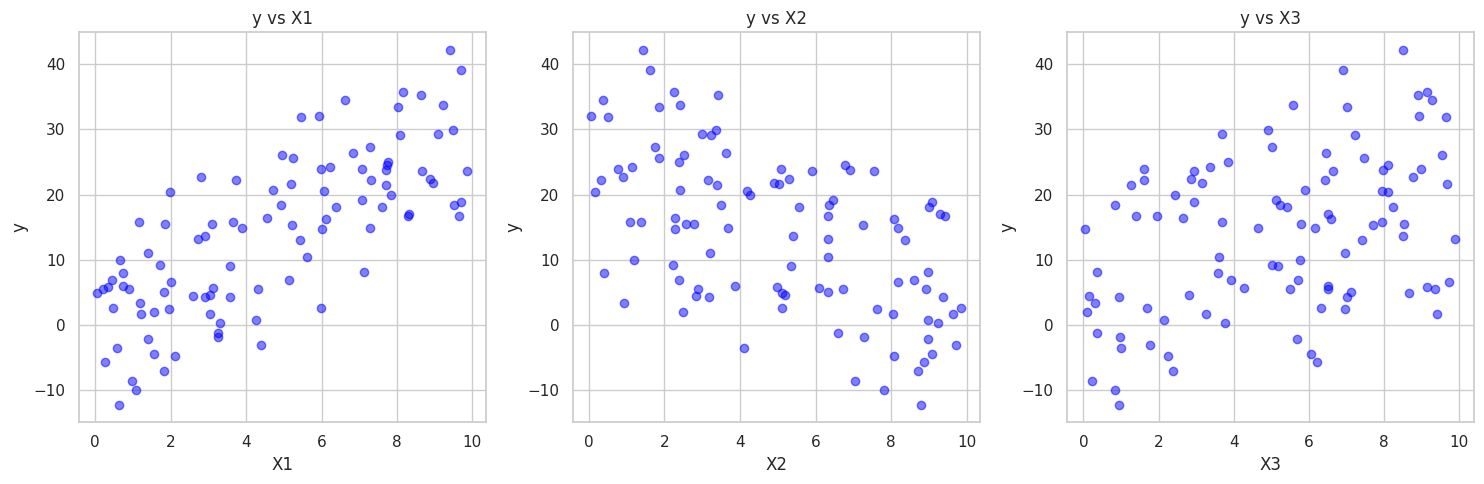

In [ ]:
# Criamos gráficos de dispersão para cada variável preditora versus y
plt.figure(figsize=(15, 5))
features = ['X1', 'X2', 'X3']
for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)
    plt.scatter(X[:, i], y, color='blue', alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('y')
    plt.title(f'y vs {feature}')
plt.tight_layout()
plt.savefig('variaveis_vs_y.png')

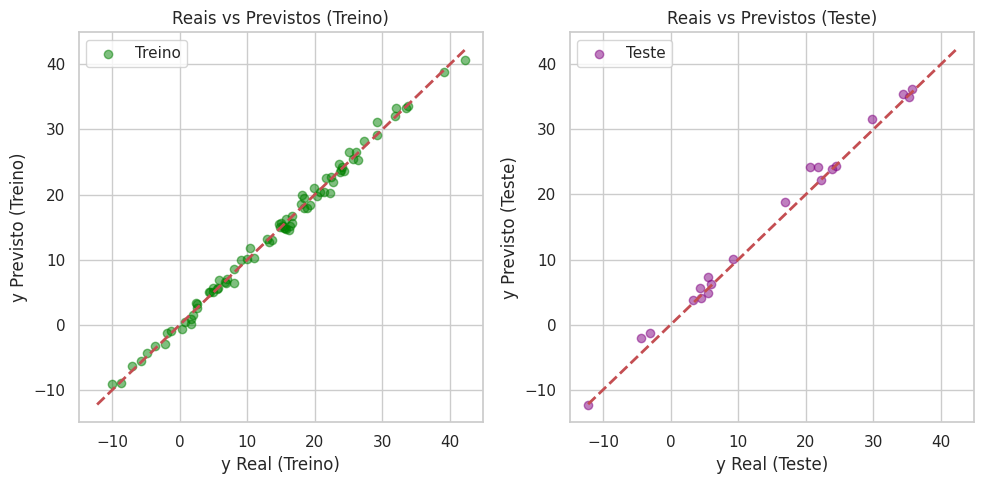

In [ ]:
# Criamos gráfico de valores reais versus previstos (treino e teste)
plt.figure(figsize=(10, 5))
# Conjunto de treino
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='green', alpha=0.5, label='Treino')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('y Real (Treino)')
plt.ylabel('y Previsto (Treino)')
plt.title('Reais vs Previstos (Treino)')
plt.legend()
# Conjunto de teste
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, color='purple', alpha=0.5, label='Teste')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('y Real (Teste)')
plt.ylabel('y Previsto (Teste)')
plt.title('Reais vs Previstos (Teste)')
plt.legend()
plt.tight_layout()
plt.savefig('reais_vs_previstos.png')

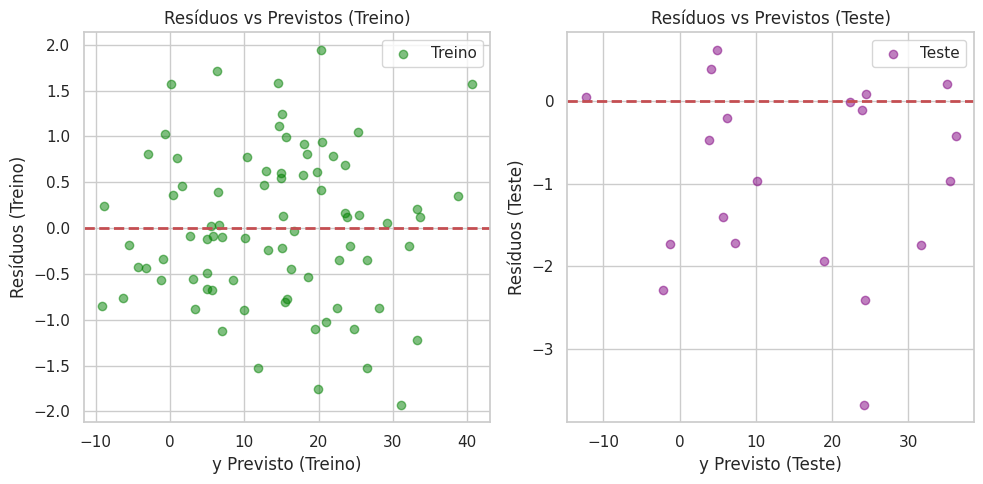

In [ ]:
# Criamos gráfico de resíduos (treino e teste)
plt.figure(figsize=(10, 5))
# Resíduos do conjunto de treino
plt.subplot(1, 2, 1)
train_residuals = y_train - y_train_pred
plt.scatter(y_train_pred, train_residuals, color='green', alpha=0.5, label='Treino')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('y Previsto (Treino)')
plt.ylabel('Resíduos (Treino)')
plt.title('Resíduos vs Previstos (Treino)')
plt.legend()
# Resíduos do conjunto de teste
plt.subplot(1, 2, 2)
test_residuals = y_test - y_test_pred
plt.scatter(y_test_pred, test_residuals, color='purple', alpha=0.5, label='Teste')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('y Previsto (Teste)')
plt.ylabel('Resíduos (Teste)')
plt.title('Resíduos vs Previstos (Teste)')
plt.legend()
plt.tight_layout()
plt.savefig('residuos.png')

#### **Exemplo 14**

O conjunto de dados `Credit.csv`, que pode ser encontrado em [2], contém informações simuladas sobre 400 clientes de cartões de crédito. Nosso objetivo é prever o saldo médio do cartão de crédito (`Balance`) com base em variáveis demográficas e financeiras.

**Variáveis:**

* `Income`: Renda anual em milhares de dólares.
* `Limit`: Limite total de crédito concedido.
* `Rating`: Avaliação de crédito do cliente.
* `Cards`: Número de cartões de crédito possuídos.
* `Age`: Idade do cliente.
* `Education`: Anos de educação formal.
* `Gender`: Gênero do cliente (`Male` ou `Female`).
* `Student`: Indica se o cliente é estudante (`Yes` ou `No`).
* `Married`: Indica se o cliente é casado (`Yes` ou `No`).
* `Ethnicity`: Etnia do cliente (`Caucasian`, `Asian`, `African American`).
* `Balance`: Saldo médio do cartão de crédito em dólares (variável alvo).

In [68]:
# Importar bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [69]:
# Carregar o conjunto de dados
url = 'https://www.statlearning.com/s/Credit.csv'
df = pd.read_csv(url)

# Exibir as primeiras linhas
df.head()

,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331


In [70]:
# Verificar as colunas presentes no DataFrame
print("\nColunas do DataFrame:")
print(df.columns)


Colunas do DataFrame:
Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Own',
       'Student', 'Married', 'Region', 'Balance'],
      dtype='object')


In [71]:
# Converter variáveis categóricas em variáveis dummy
df = pd.get_dummies(df, drop_first=True)

# Exibir as primeiras linhas após o pré-processamento
df.head()

,Income,Limit,Rating,Cards,Age,Education,Balance,Own_Yes,Student_Yes,Married_Yes,Region_South,Region_West
0,14.891,3606,283,2,34,11,333,False,False,True,True,False
1,106.025,6645,483,3,82,15,903,True,True,True,False,True
2,104.593,7075,514,4,71,11,580,False,False,False,False,True
3,148.924,9504,681,3,36,11,964,True,False,False,False,True
4,55.882,4897,357,2,68,16,331,False,False,True,True,False


In [72]:
# Definir variáveis independentes (X) e dependente (y)
X = df.drop('Balance', axis=1)
y = df['Balance']

Note que

In [73]:
np.shape(X)

(400, 11)

In [74]:
np.shape(y)

(400,)

In [75]:
# Salvamos os nomes das colunas para uso posterior
colunas_treinamento = X.columns

In [76]:
# Dividimos os dados em conjuntos de treinamento e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
# Criamos o modelo de regressão linear
modelo = LinearRegression()

# Treinamos o modelo com os dados de treinamento
modelo.fit(X_train, y_train)

LinearRegression()

In [78]:
# Fazemos previsões com os dados de teste
y_pred = modelo.predict(X_test)

In [79]:
# Calculamos o erro quadrático médio (MSE) e o coeficiente de determinação (R²)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Erro Quadrático Médio (MSE): {mse:.2f}')
print(f'Coeficiente de Determinação (R²): {r2:.2f}')

Erro Quadrático Médio (MSE): 7974.86
Coeficiente de Determinação (R²): 0.95


Façamos agora os cálculos sem teste/treinamento:

In [80]:
modelo2 = LinearRegression()
modelo2.fit(X, y)

LinearRegression()

In [81]:
y_pred2 = modelo2.predict(X)

In [82]:
mse2 = mean_squared_error(y, y_pred2)
rr2 = r2_score(y, y_pred2)
print(f'Erro Quadrático Médio (MSE): {mse2:.2f}')
print(f'Coeficiente de Determinação (R²): {rr2:.2f}')

Erro Quadrático Médio (MSE): 9466.83
Coeficiente de Determinação (R²): 0.96


In [83]:
# Exibimos os coeficientes do modelo
coeficientes = pd.DataFrame({'Variável': X.columns, 'Coeficiente': modelo.coef_})
print(coeficientes)

        Variável  Coeficiente
0         Income    -7.554059
1          Limit     0.198058
2         Rating     0.971292
3          Cards    19.123826
4            Age    -0.603695
5      Education    -1.078674
6        Own_Yes   -12.493725
7    Student_Yes   418.435398
8    Married_Yes    -6.150365
9   Region_South    11.517153
10   Region_West    13.295548


In [84]:
# Configuramos estilo dos gráficos
sns.set(style="whitegrid")

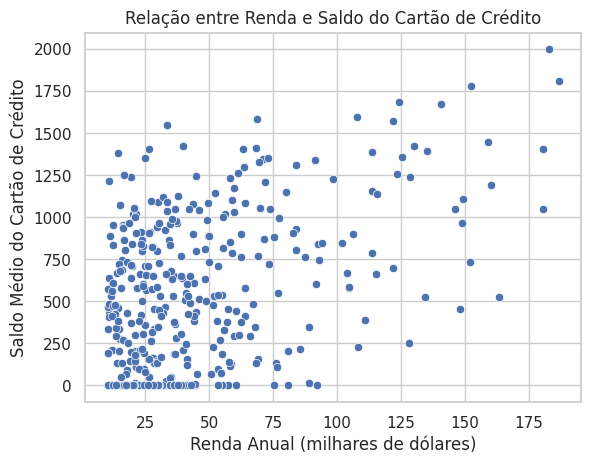

In [85]:
# Plotamos a relação entre renda e saldo do cartão de crédito
sns.scatterplot(x='Income', y='Balance', data=df)
plt.title('Relação entre Renda e Saldo do Cartão de Crédito')
plt.xlabel('Renda Anual (milhares de dólares)')
plt.ylabel('Saldo Médio do Cartão de Crédito')
plt.show()

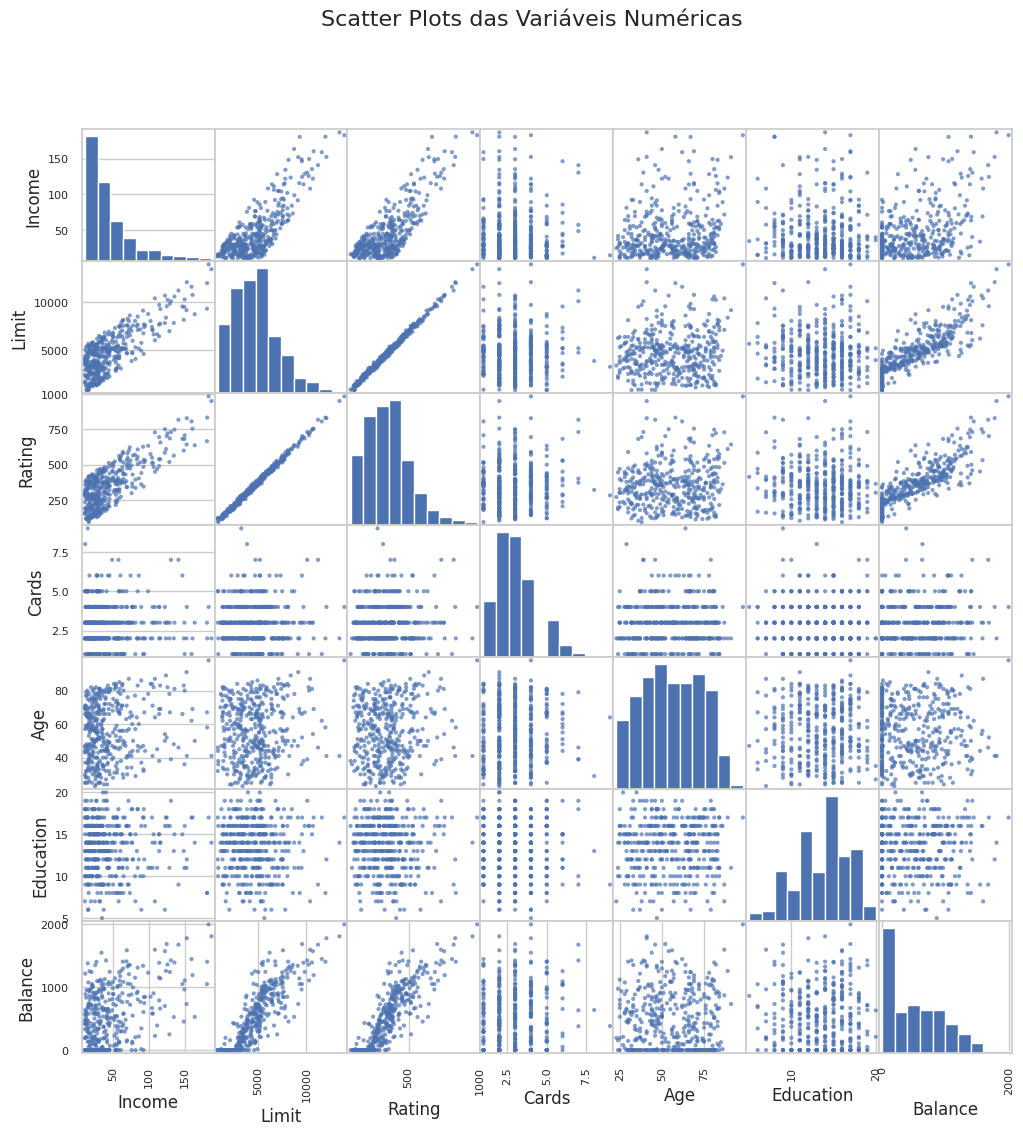

In [86]:
from pandas.plotting import scatter_matrix
# Selecionamos apenas as colunas numéricas
df_numerico = df.select_dtypes(include=['float64', 'int64'])

# Geramos a matriz de scatter plots
scatter_matrix(df_numerico, figsize=(12, 12), diagonal='hist', alpha=0.7)

# Exibimos os gráficos
plt.suptitle('Scatter Plots das Variáveis Numéricas', fontsize=16)
plt.show()

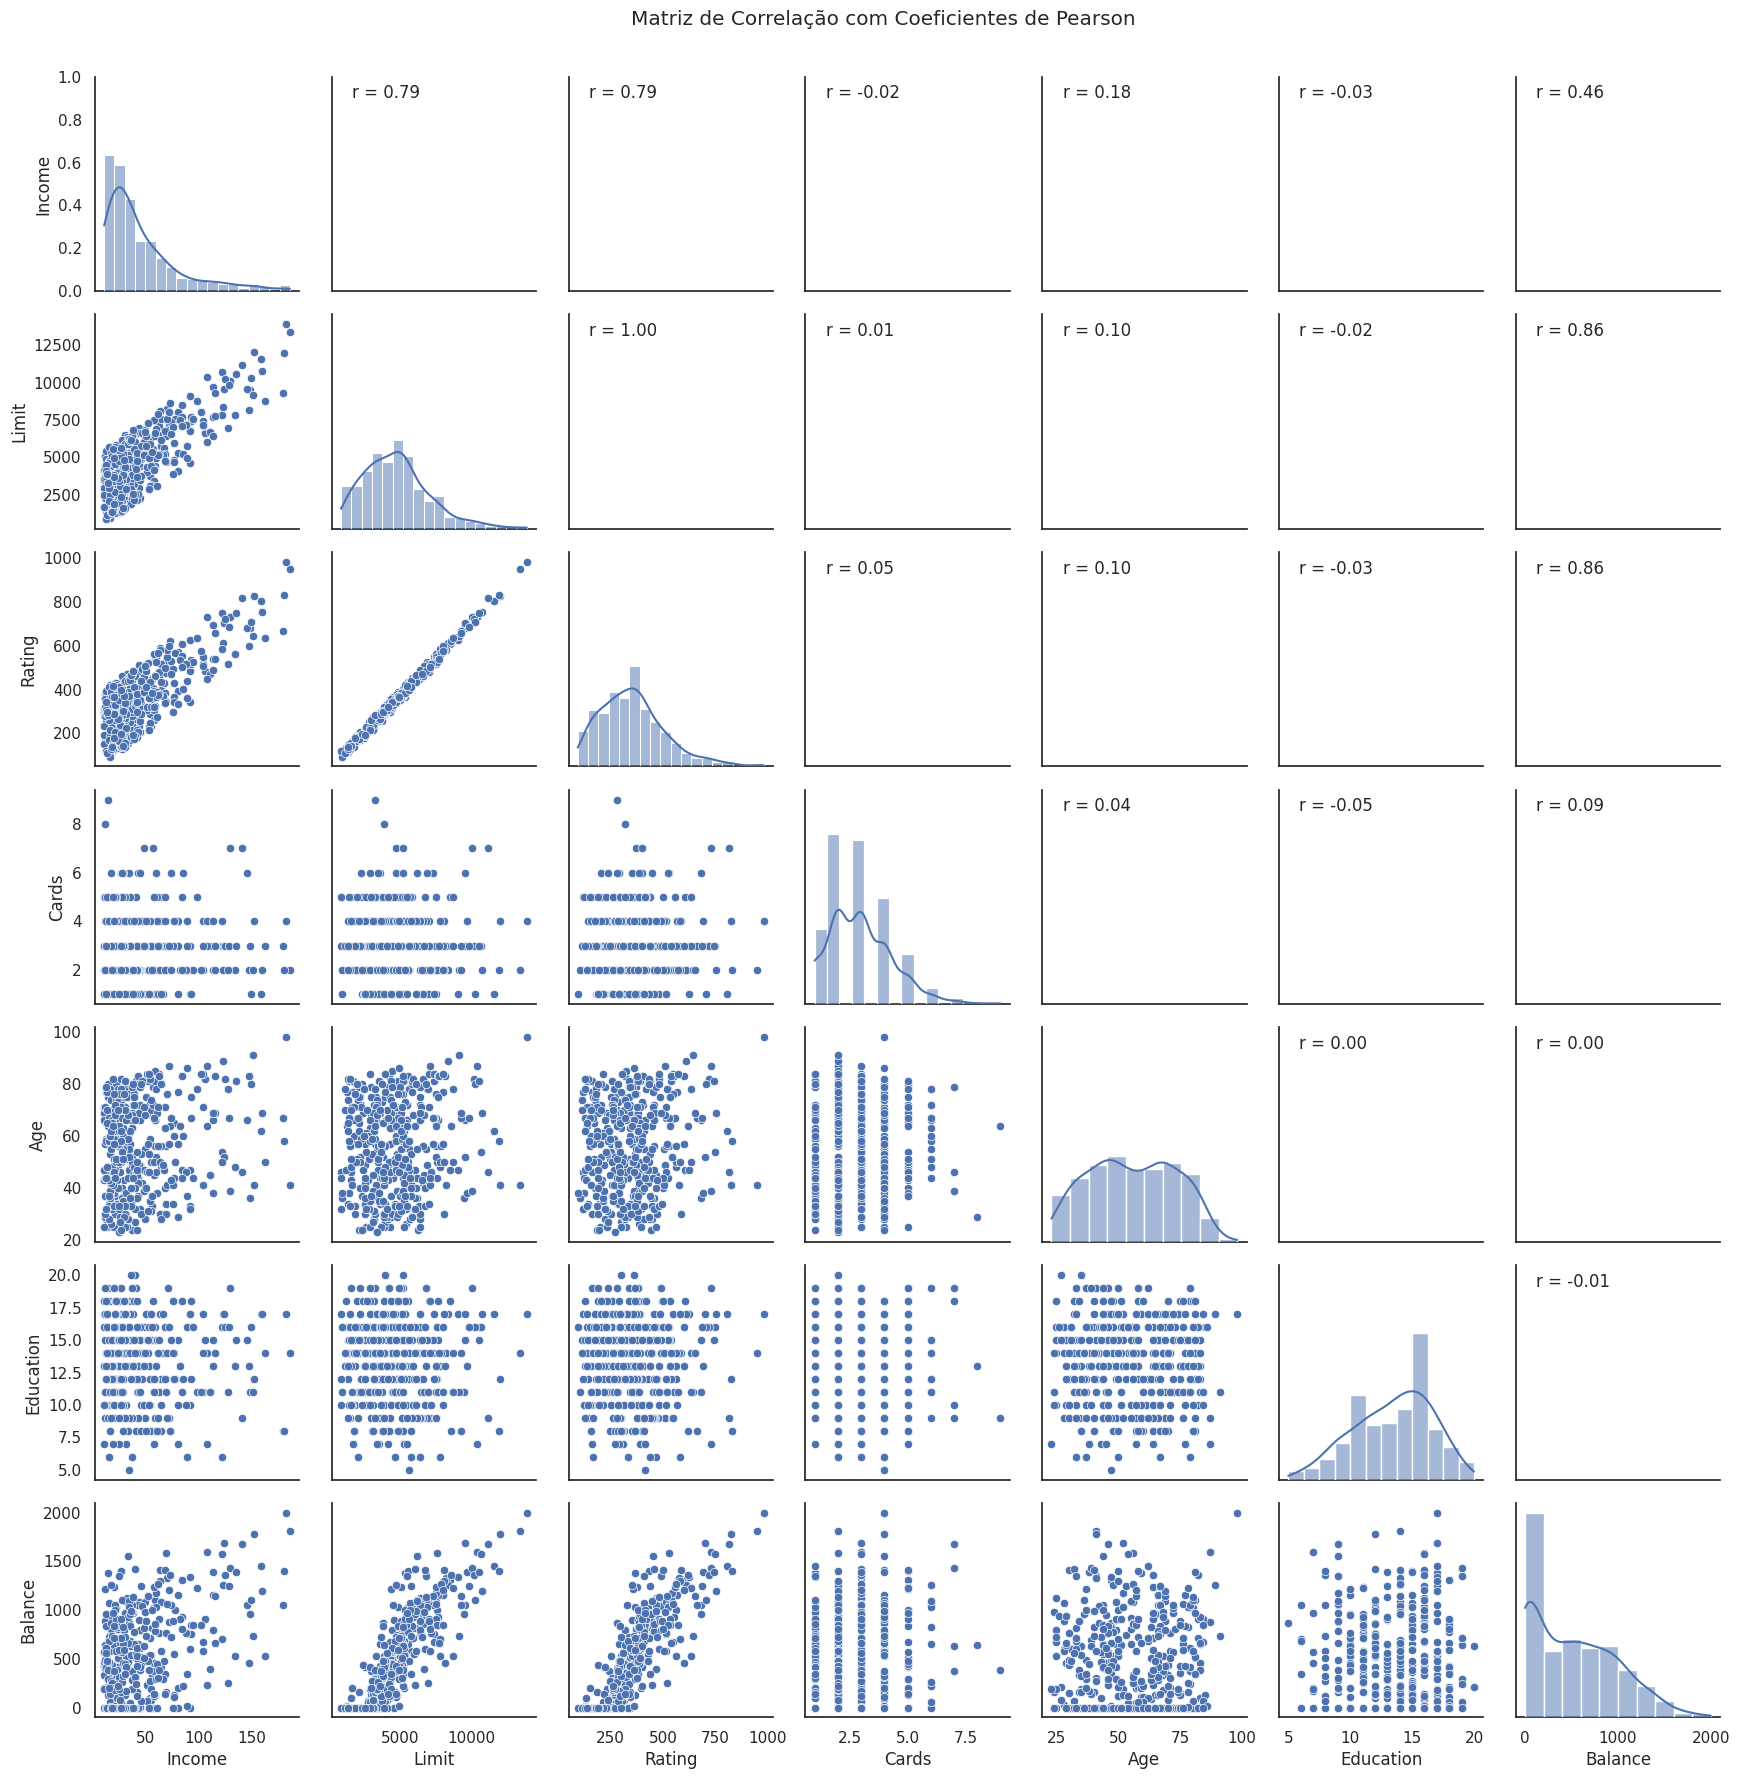

In [87]:
from scipy.stats import pearsonr
# Função para calcular o coeficiente de correlação de Pearson
def corrfunc(x, y, **kws):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f'r = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes)

# Criamos a matriz de gráficos de dispersão com os coeficientes de correlação
sns.set(style='white')
g = sns.PairGrid(df_numerico)
g.map_lower(sns.scatterplot)
g.map_diag(sns.histplot, kde=True)
g.map_upper(corrfunc)

plt.suptitle('Matriz de Correlação com Coeficientes de Pearson', y=1.02)
plt.show()

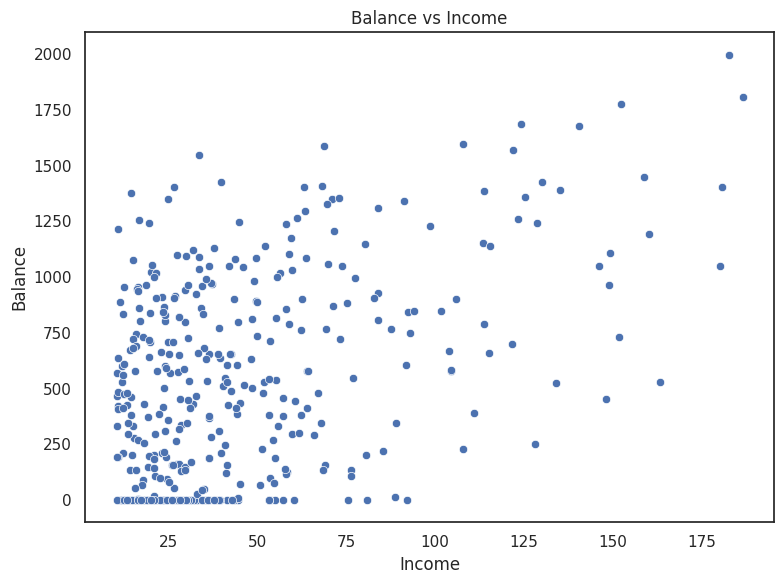

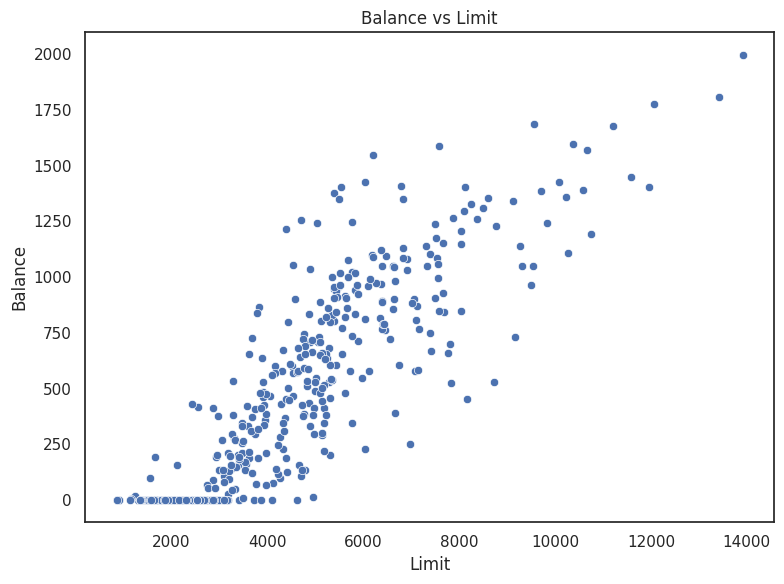

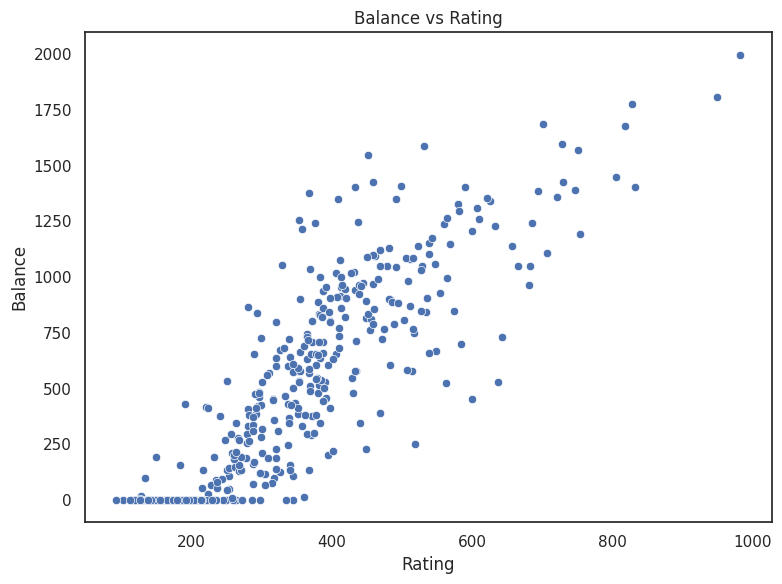

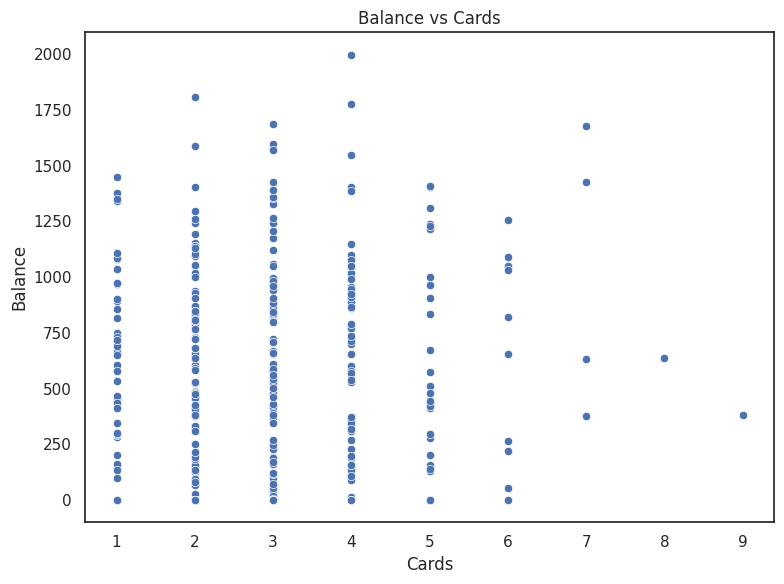

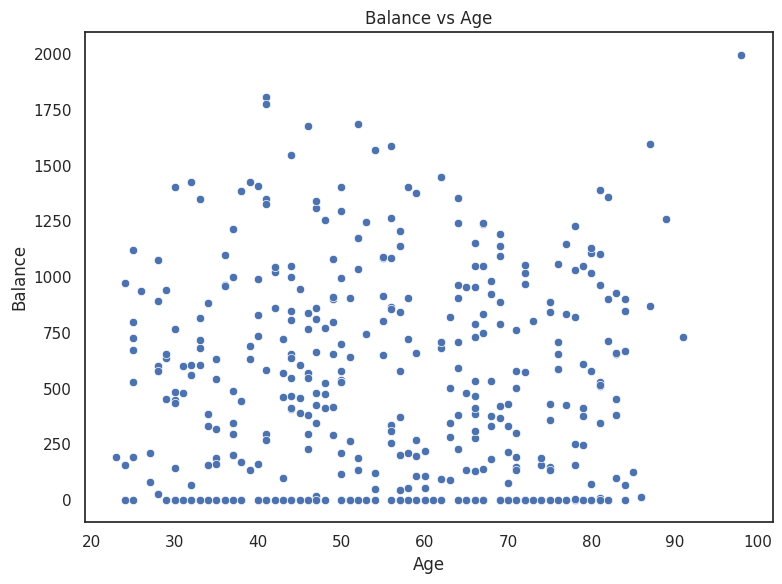

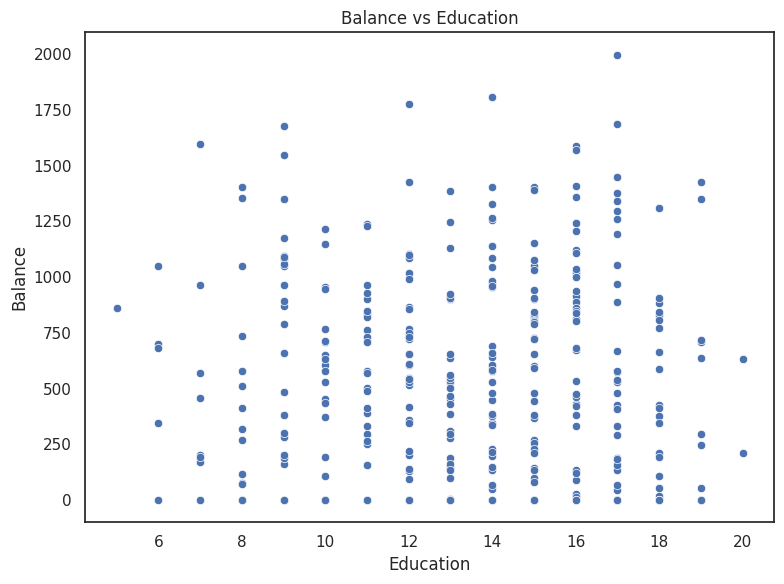

In [88]:
# Selecionar apenas as colunas numéricas
df_numerico = df.select_dtypes(include=['float64', 'int64'])

# Identificar a variável alvo
target = 'Balance'

# Criamos gráficos de dispersão de Balance em relação às outras variáveis numéricas
for column in df_numerico.columns:
    if column != target:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=df_numerico[column], y=df_numerico[target])
        plt.title(f'{target} vs {column}')
        plt.xlabel(column)
        plt.ylabel(target)
        plt.tight_layout()
        plt.show()

In [89]:
# Criamos novos exemplos para previsão
novos_clientes = pd.DataFrame({
    'Income': [30, 60, 90],
    'Limit': [3000, 6000, 9000],
    'Rating': [200, 400, 600],
    'Cards': [2, 4, 6],
    'Age': [25, 45, 65],
    'Education': [12, 16, 20],
    'Gender_Male': [1, 0, 1],
    'Student_Yes': [0, 1, 0],
    'Married_Yes': [1, 0, 1],
    'Ethnicity_Asian': [0, 1, 0],
    'Ethnicity_Caucasian': [1, 0, 1]
})

# Reindexar para garantir correspondência de colunas
novos_clientes = novos_clientes.reindex(columns=colunas_treinamento, fill_value=0)

# Prever o saldo do cartão de crédito para os novos clientes
saldos_previstos = modelo.predict(novos_clientes)

# Exibir as previsões
print("\nPrevisões de saldo do cartão de crédito para novos clientes:")
for i, saldo in enumerate(saldos_previstos):
    print(f"Cliente {i+1}: Saldo previsto = ${saldo:.2f}")


Previsões de saldo do cartão de crédito para novos clientes:
Cliente 1: Saldo previsto = $100.82
Cliente 2: Saldo previsto = $1109.07
Cliente 3: Saldo previsto = $1268.16


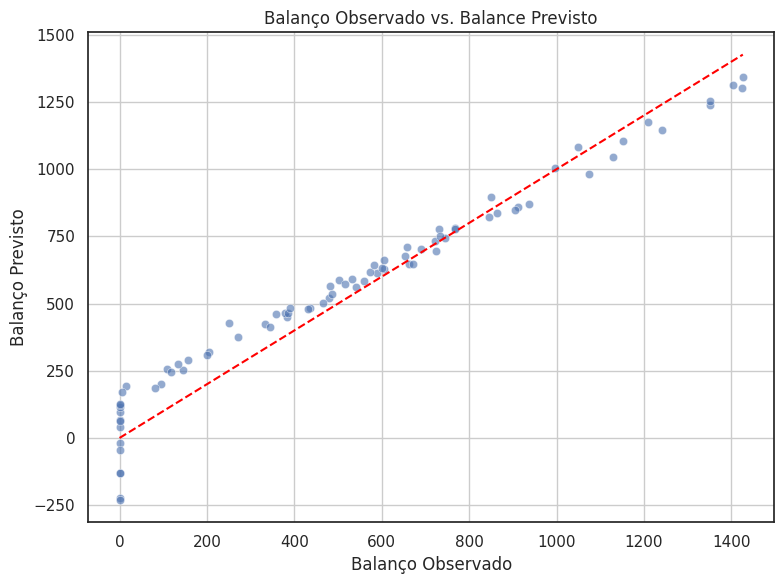

In [90]:
# Geramos o gráfico: Balance Observado vs. Balance Previsto
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Balanço Observado')
plt.ylabel('Balanço Previsto')
plt.title('Balanço Observado vs. Balance Previsto')
plt.grid(True)
plt.tight_layout()
plt.show()

Notemos que para o gráfico acima:

- Pontos próximos à linha vermelha tracejada: Indicam que o modelo previu corretamente o saldo ou balanço (Balance) para essas observações.
- Pontos distantes da linha: Sugerem que o modelo teve dificuldade em prever corretamente o saldo ou balanço para essas observações, podendo indicar outliers ou variáveis importantes não incluídas no modelo.

### Exercícios

**1.** Use os dados de advertising.csv [2] e use o método de gradientes descendentes para determinar os ajustes lineares univariados de vendas por propaganda em (i) TV, (ii) rádio e (iii) jornal.

**2.** No exemplo envolvendo o dataset Auto MPG, determine  polinômios de regressão para ajustar as curvas mpg vs horsepower e mpg x weight.  Faça algumas predições.

**3.** No exemplo 8 refaça os cálculos usando treino e teste.

### Bibliografia

**1.** Snehan Kekre, Linear Regression with NumPy and Python, Coursera Project Network, https://www.coursera.org/projects/linear-regression-numpy-python

**2.** Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani. An Introduction to Statistical Learning, 2nd ed., Springer, 2021.  https://www.statlearning.com/resources-second-edition